# Classify lung cancer subtypes — and publish every figure as you go

Welcome! This notebook is a real analysis on real data: gene expression for
**1,051 lung tumors** from The Cancer Genome Atlas (TCGA), spanning the two
major subtypes — adenocarcinoma (**LUAD**) and squamous cell carcinoma
(**LUSC**). We'll ask: *can a simple machine-learning model tell the two
subtypes apart from expression alone — and which genes give it away?*

Along the way you'll see what makes GoFigr different from a plain notebook:

- **Every figure publishes itself.** As each plot renders, it lands in your
  GoFigr account with the exact code, data fingerprint, and environment that
  produced it. No screenshots, no `final_v2_REALLY_final.png`.
- **One figure is interactive**: viewers can re-slice it by clinical subgroup
  in the GoFigr portal, without rerunning the notebook.
- **Re-running creates revisions, not overwrites** — try it at the end.

▶️ **Run everything now** (menu: *Run → Run All Cells*, ~1 minute), keep
[app.gofigr.io](https://app.gofigr.io) open in another tab, and watch the
figures arrive as they render.

## Setup — this is all of it

The line below is the entire GoFigr integration. Your instance is already
signed in to your account, so there are no API keys to paste. After
`%load_ext gofigr`, every matplotlib figure this notebook shows is published
automatically into the analysis named here (created on first run).


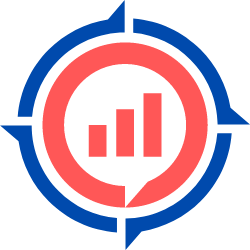

In [1]:
%load_ext gofigr

configure(
    analysis=FindByName("TCGA Lung Cancer Analysis (LUAD + LUSC)", create=True),
)


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from gofigr.reproducible import reproducible, DropdownParam, StaticParam

from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import StandardScaler

%config InlineBackend.figure_format = "retina"

# GoFigr brand palette. Navy vs coral is a blue/red axis, so the pair stays
# distinguishable under both protan and deutan color vision.
LUAD_NAVY = "#004aad"
LUSC_CORAL = "#e04b4b"
NEUTRAL = "#8a94a6"
INK = "#3a4354"

# figure.dpi is also captured by @reproducible, so the portal re-renders at
# the same resolution; savefig.dpi controls the published PNGs.
plt.rcParams.update({
    "figure.dpi": 125,
    "savefig.dpi": 200,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.edgecolor": "#c3c9d5",
    "axes.grid": True,
    "grid.color": "#e8ebf1",
    "grid.linewidth": 0.8,
    "axes.axisbelow": True,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.titlepad": 12,
    "axes.labelsize": 11,
    "axes.labelcolor": INK,
    "xtick.color": "#5b6472",
    "ytick.color": "#5b6472",
    "legend.frameon": False,
})


## Load the data

The expression matrix ships with your instance: log2(TPM+1) values for
primary tumor samples, genes as columns, plus clinical metadata (subtype,
gender, stage). It was prepared from the public TCGA cohorts by
[`download_tcga.R`](download_tcga.R), which you can rerun yourself later.

`gf.read_parquet` works exactly like `pandas.read_parquet` — but GoFigr also
fingerprints the file, so every figure downstream records *which data* it
came from.


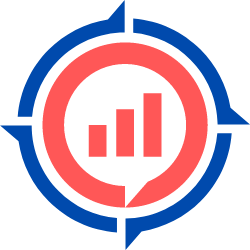


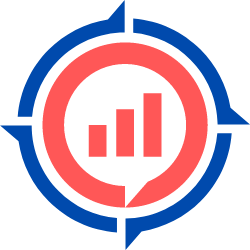

Samples: 1051 | Genes: 1234
LUAD: 540 | LUSC: 511


In [3]:
expr = gf.read_parquet("data/expr_tumor.parquet")
clinical = gf.read_parquet("data/clinical_tumor.parquet")

X = expr.values
y = (clinical["cohort"] == "LUSC").astype(int).values  # 1 = LUSC, 0 = LUAD
gene_names = expr.columns.tolist()

# Build a combined frame for the reproducible figure
clf_df = clinical.copy()
clf_df["stage_simple"] = clf_df["stage"].str.extract(r"Stage (I+V?|I)")[0]

print(f"Samples: {X.shape[0]} | Genes: {X.shape[1]}")
print(f"LUAD: {(y == 0).sum()} | LUSC: {(y == 1).sum()}")

## Figure 1 — which genes give the subtype away?

We train an L1-regularized (lasso) logistic regression. L1 pushes most
coefficients to exactly zero, so the genes that survive are the ones doing
the discriminating: positive coefficients push toward LUSC, negative toward
LUAD.

The biology is well established, which makes this a nice sanity check:
squamous tumors overexpress keratins and *TP63*, adenocarcinomas express
surfactant proteins and *NKX2-1*. If the model is learning real signal,
those families should dominate the chart.

The moment the bars render below, this figure is **already published** —
find it in your analysis at [app.gofigr.io](https://app.gofigr.io), with
this cell's code attached.

Non-zero coefficients: 49 / 1234 genes


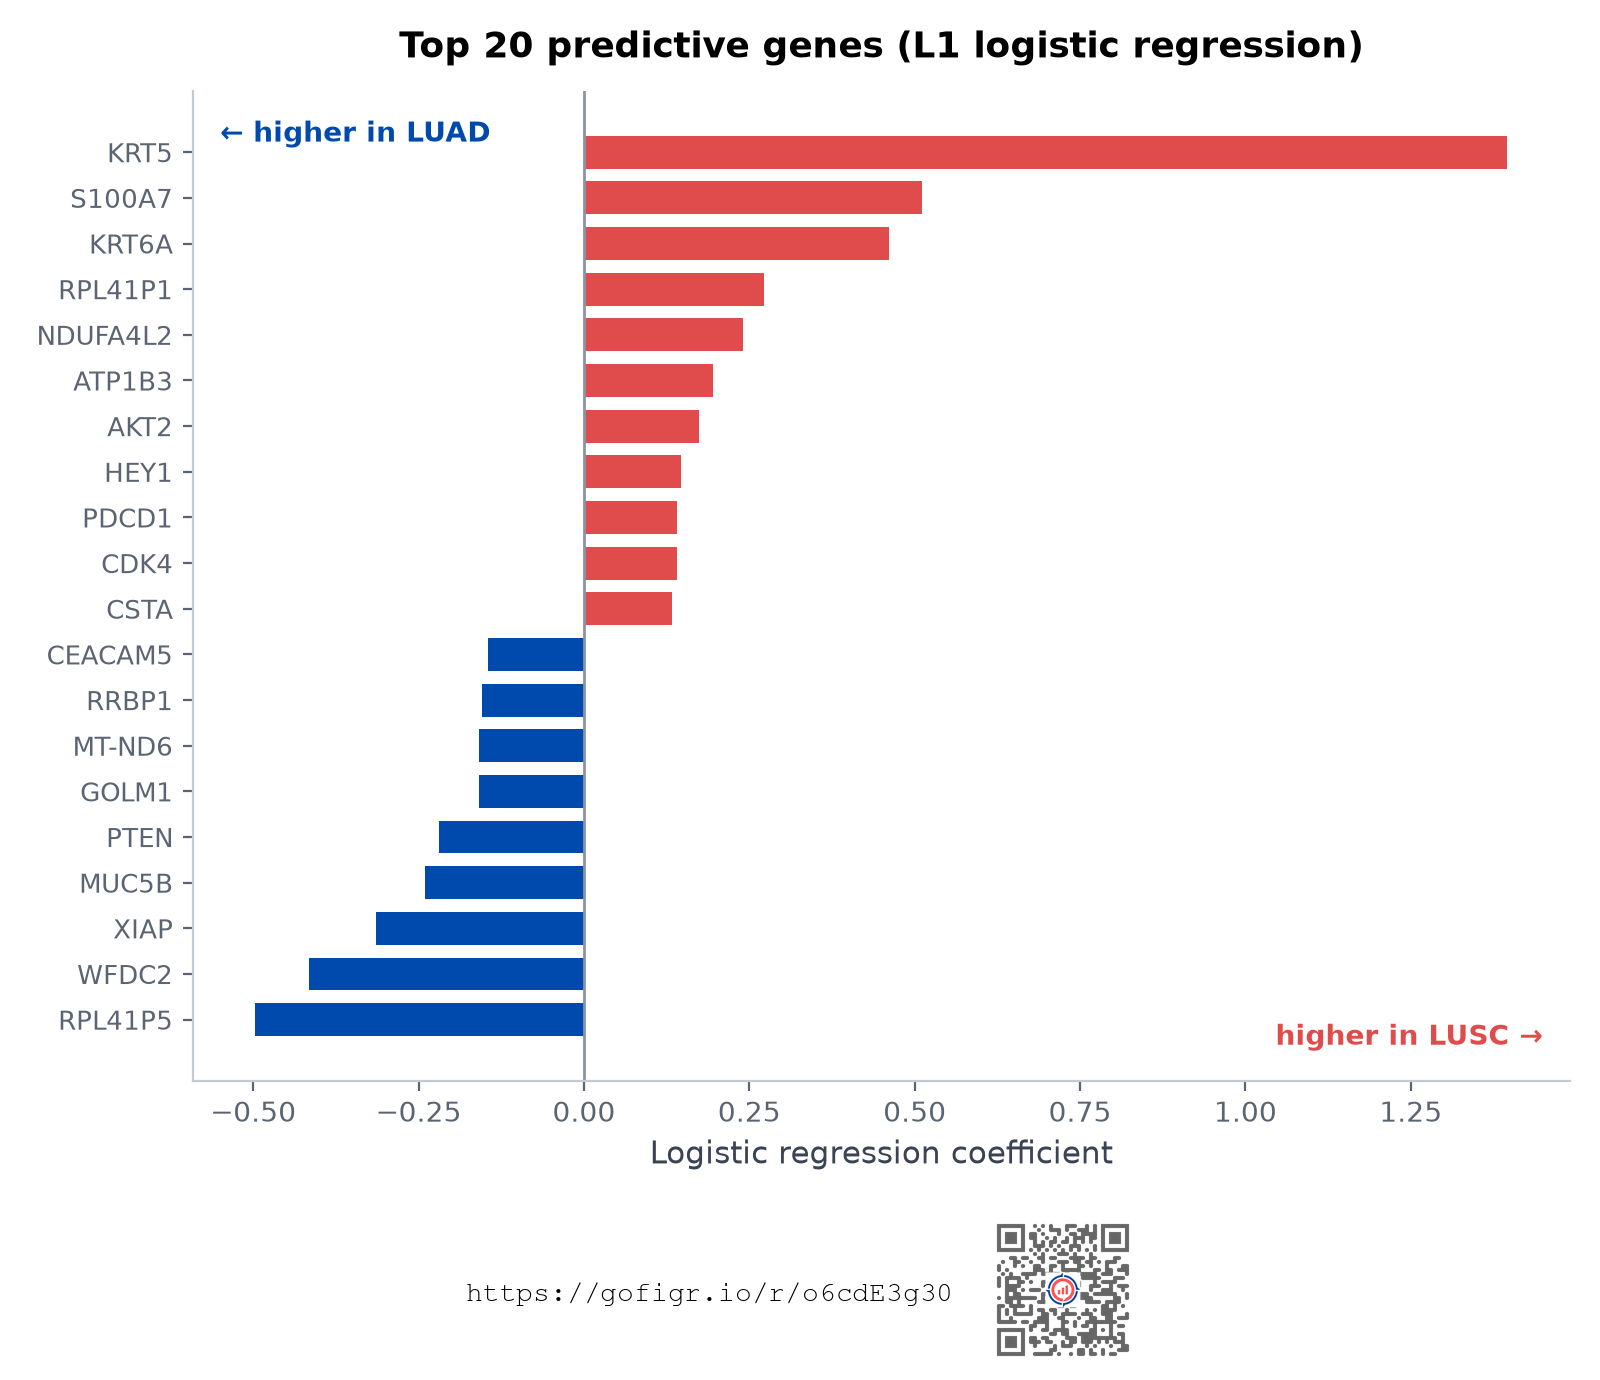


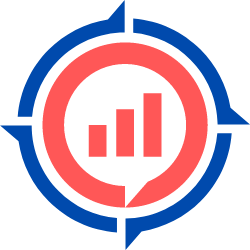
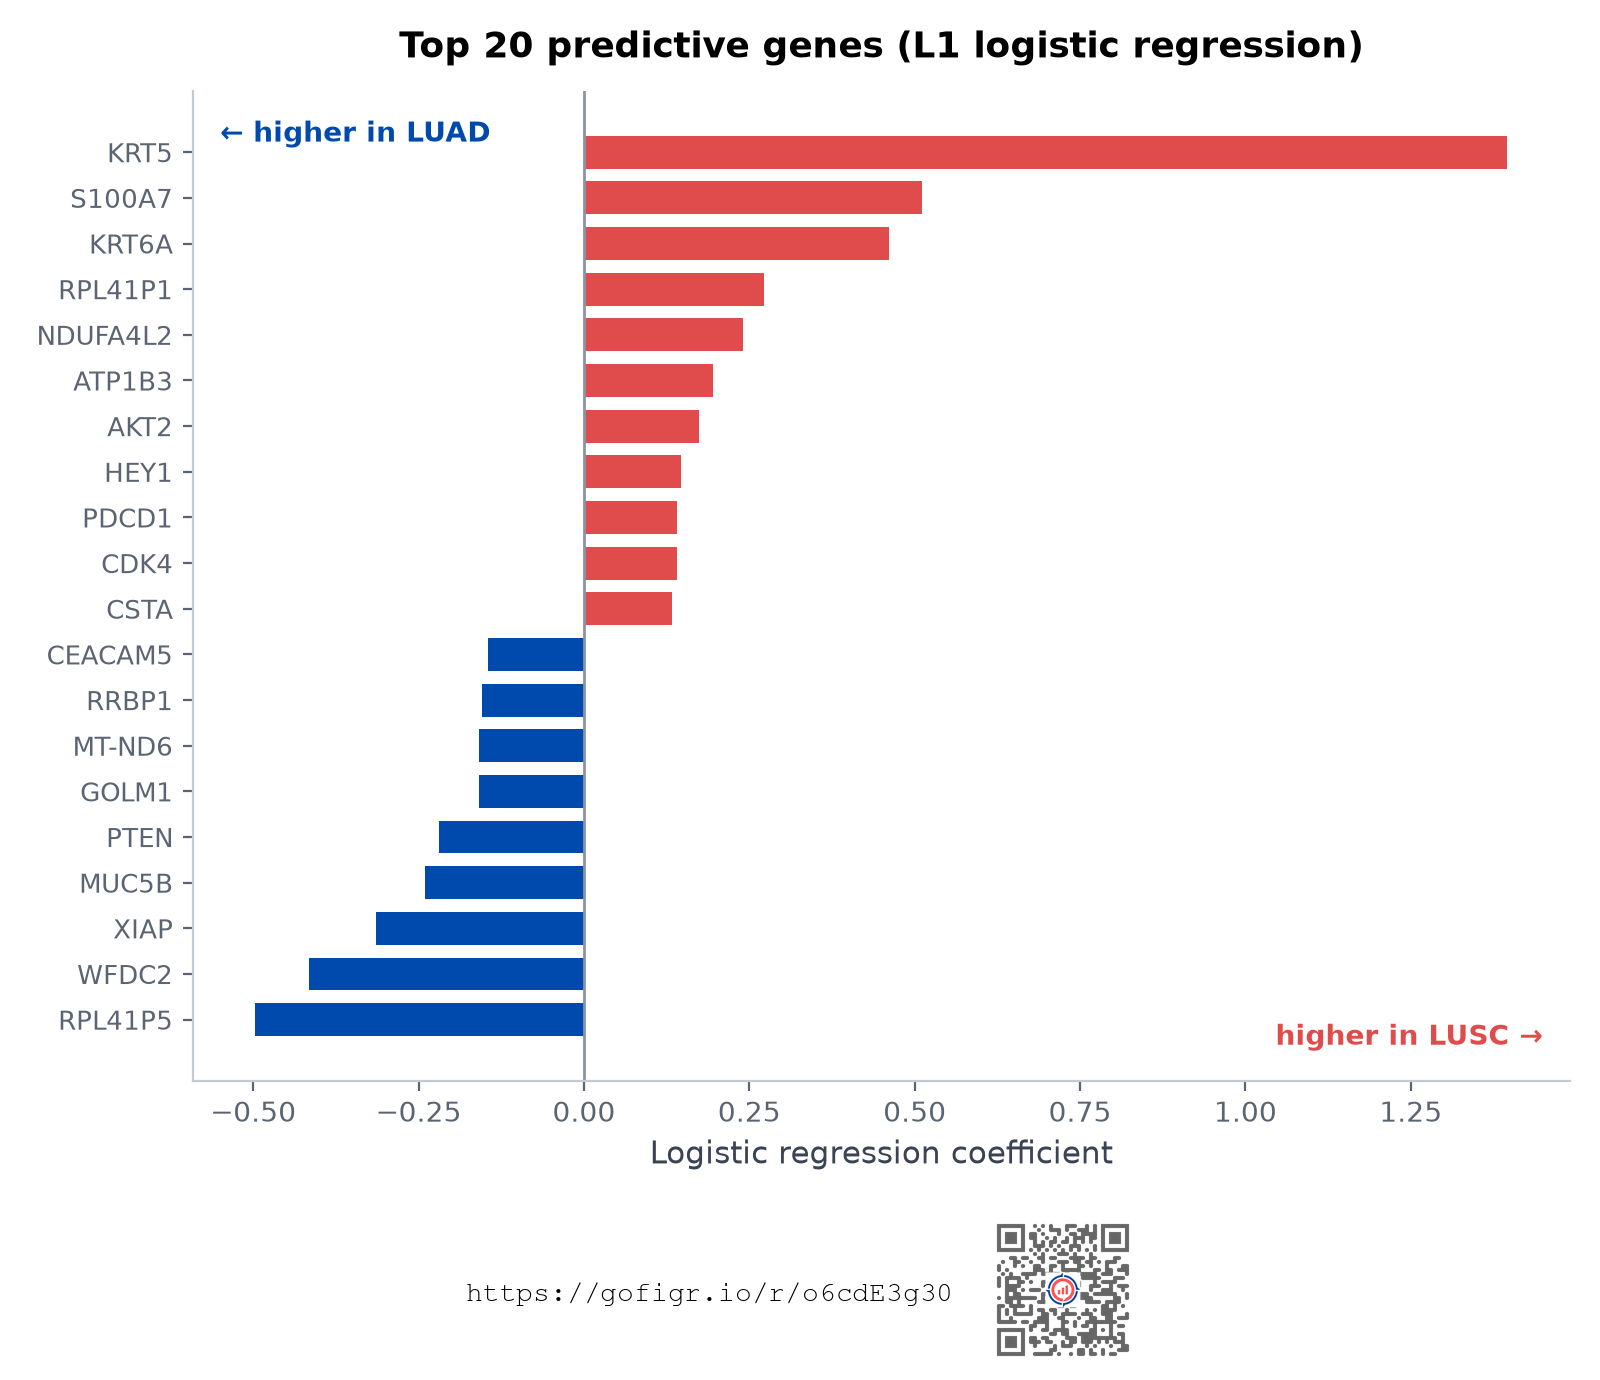
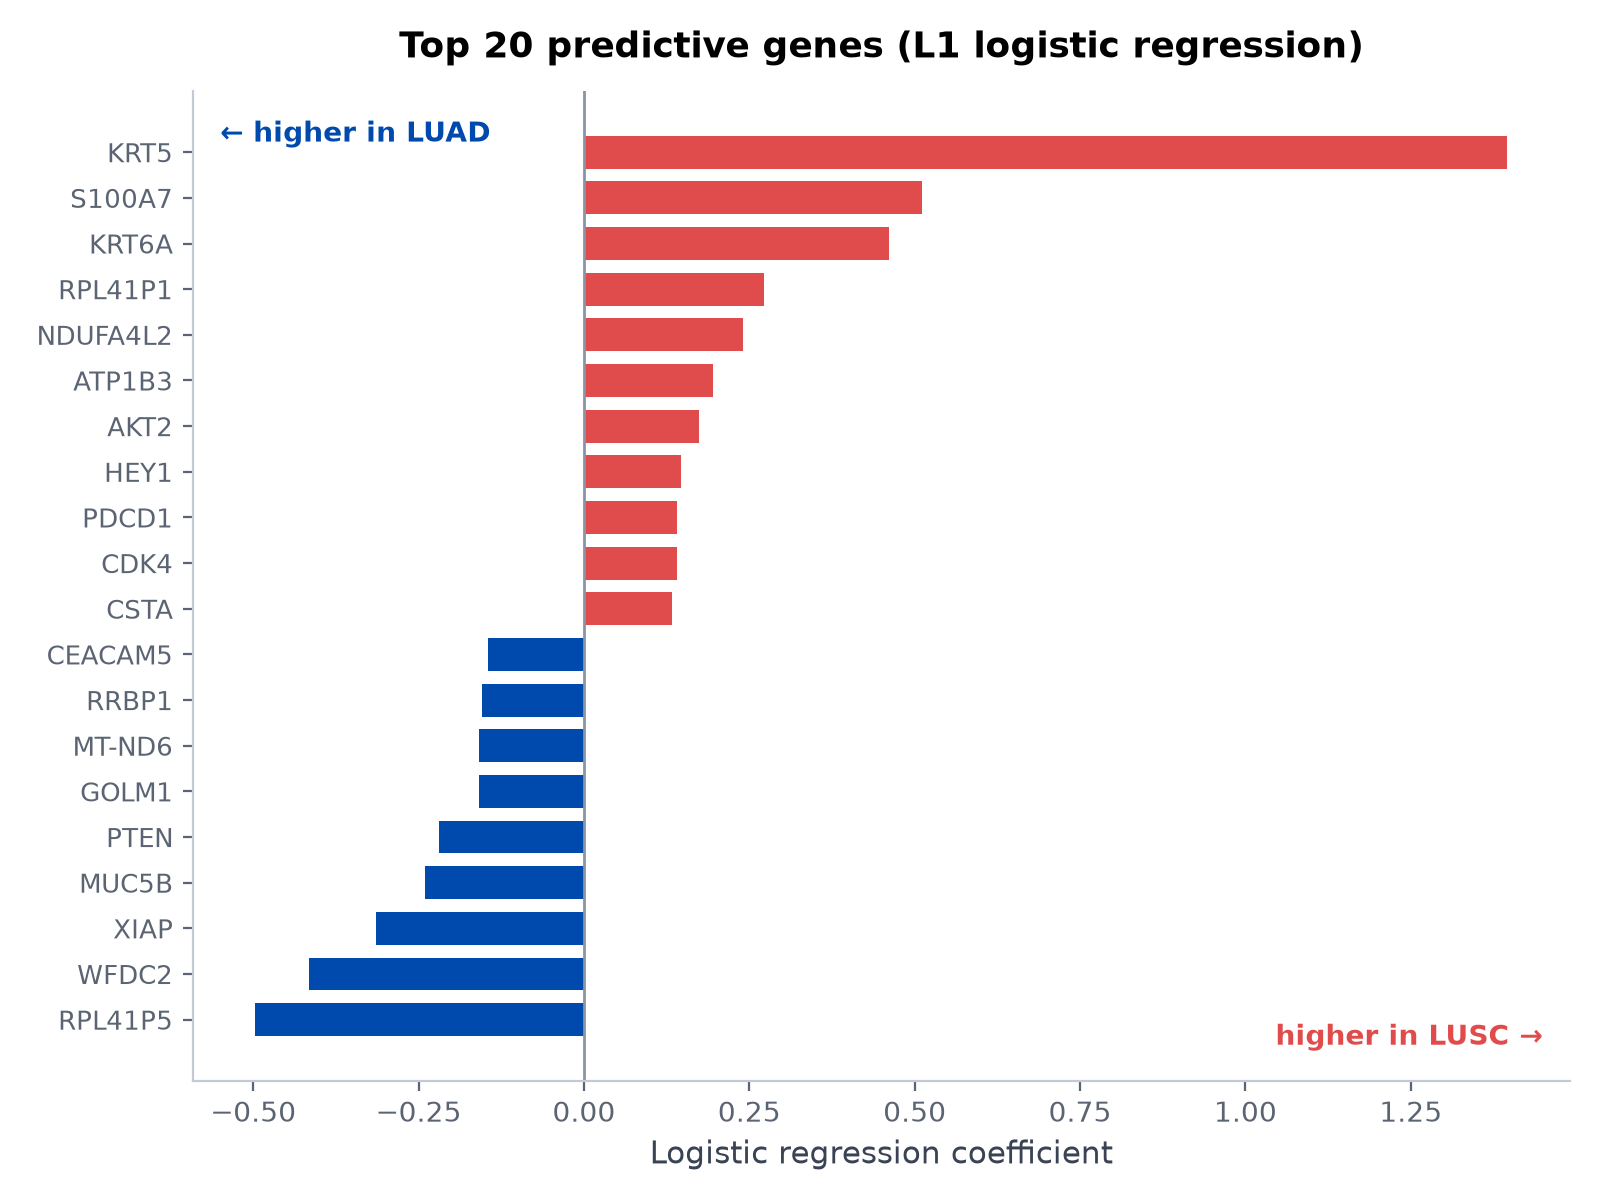
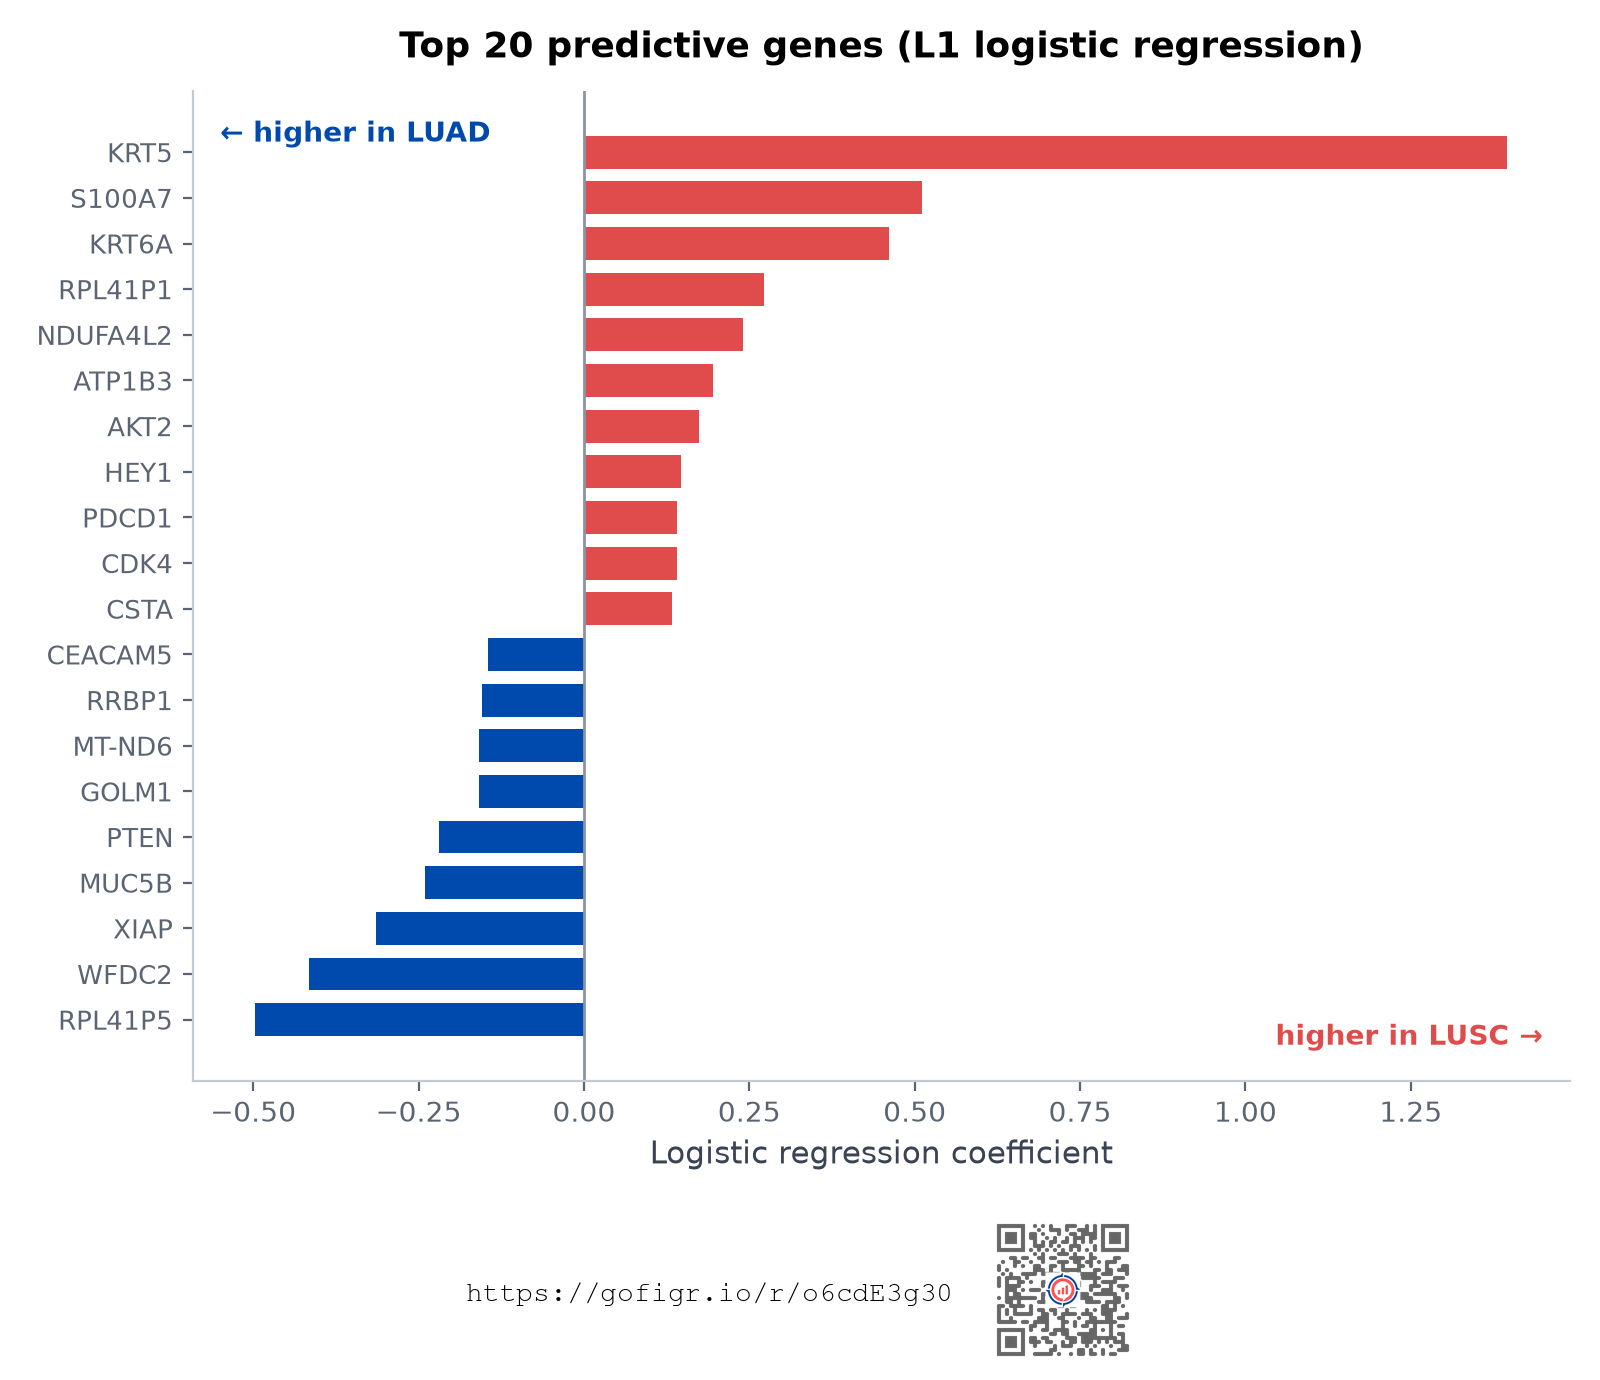
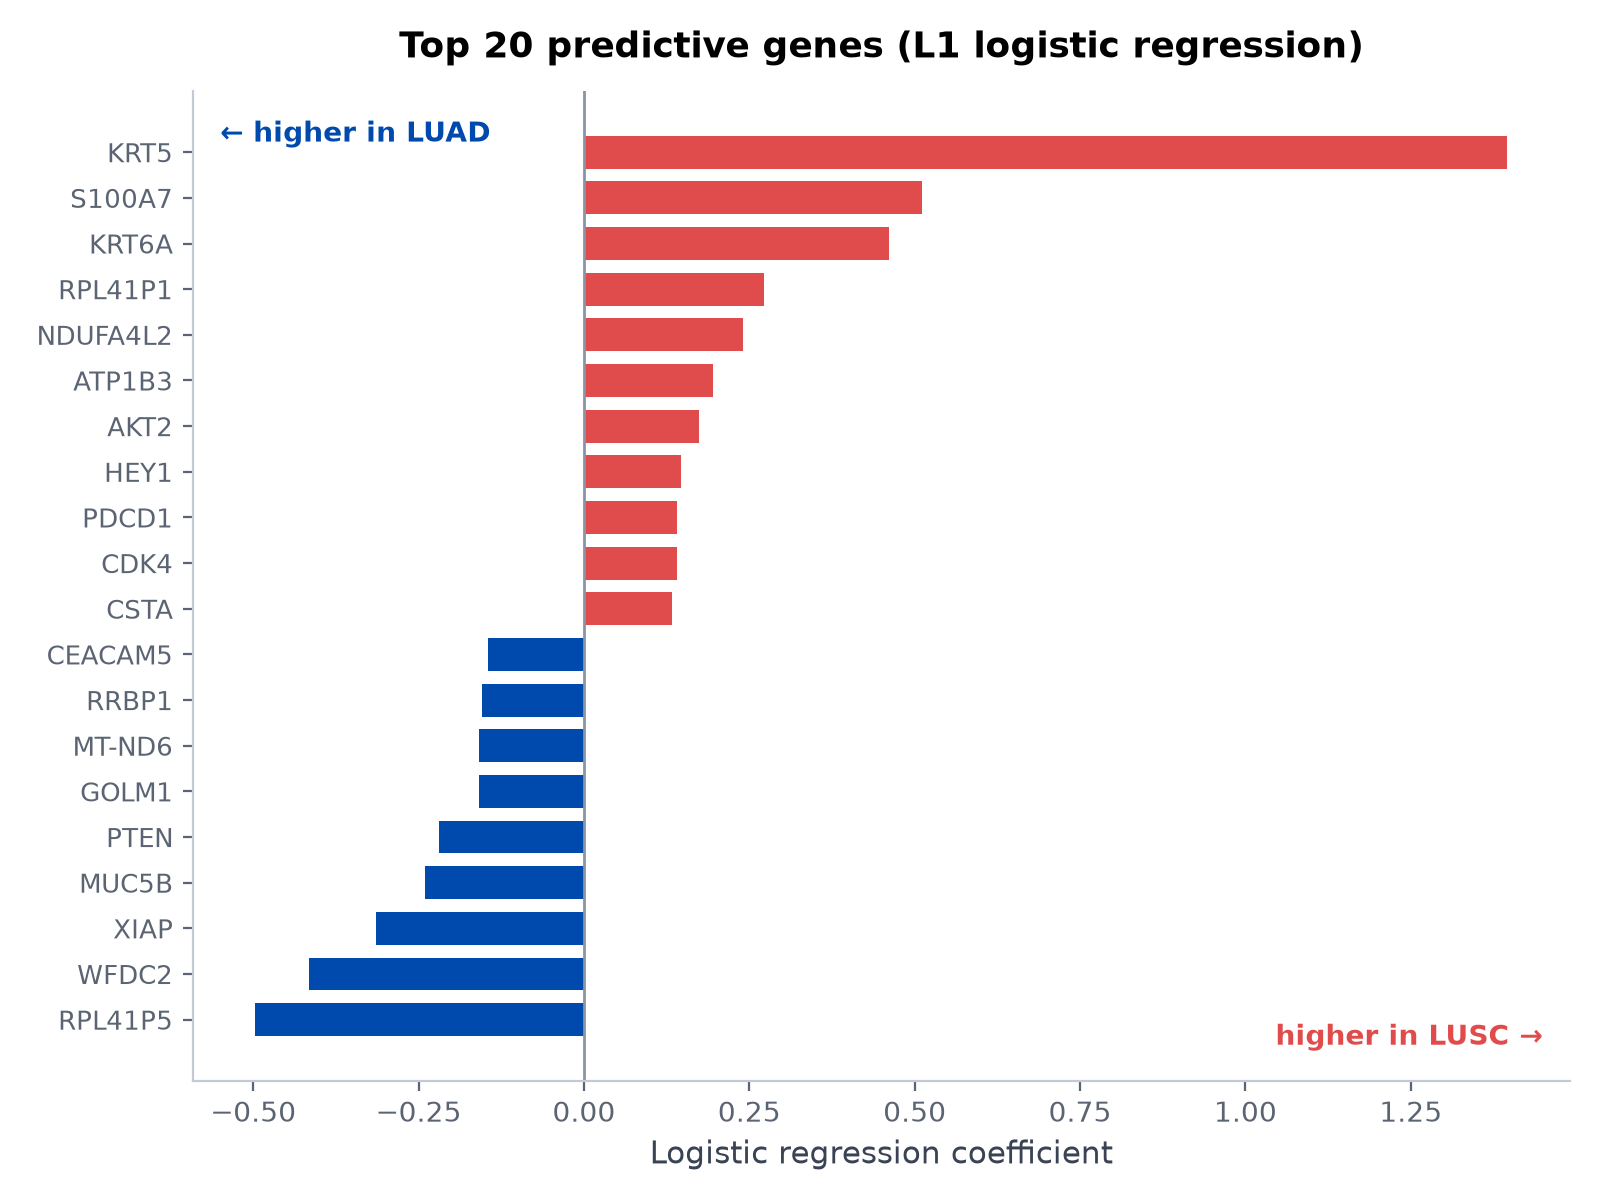

In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

model = LogisticRegression(l1_ratio=1, C=0.1, solver="liblinear", random_state=42)
model.fit(X_scaled, y)

# Extract non-zero coefficients
coefs = pd.Series(model.coef_[0], index=gene_names)
nonzero = coefs[coefs != 0].sort_values()

print(f"Non-zero coefficients: {len(nonzero)} / {len(gene_names)} genes")

# Plot top 20 by absolute magnitude
top_n = 20
top_genes = nonzero.reindex(nonzero.abs().nlargest(top_n).index).sort_values()

fig, ax = plt.subplots(figsize=(8, 6))
colors = [LUAD_NAVY if v < 0 else LUSC_CORAL for v in top_genes.values]
ax.barh(top_genes.index, top_genes.values, color=colors, height=0.72)
ax.grid(axis="x")
ax.grid(axis="y", visible=False)
ax.set_xlabel("Logistic regression coefficient")
ax.set_title(f"Top {top_n} predictive genes (L1 logistic regression)")
ax.axvline(0, color=NEUTRAL, linewidth=1)
ax.tick_params(axis="y", labelsize=9.5)

# Direction labels double as the legend: color = subtype, everywhere.
# Top-left and bottom-right are empty by construction (bars sorted by sign).
ax.text(0.02, 0.97, "\u2190 higher in LUAD", transform=ax.transAxes, va="top",
        ha="left", fontsize=10, color=LUAD_NAVY, fontweight="bold")
ax.text(0.98, 0.03, "higher in LUSC \u2192", transform=ax.transAxes, va="bottom",
        ha="right", fontsize=10, color=LUSC_CORAL, fontweight="bold")

plt.tight_layout()
plt.show()


## Figure 2 — how well does it discriminate? (interactive)

Coefficients tell us *what* the model uses; a ROC curve tells us *how well*
it separates the classes. We use 5-fold cross-validation so every prediction
is made on data the model never saw during training.

This one is special: it's wrapped in `@reproducible`, which publishes the
plotting *function*, not just the picture. In the GoFigr portal, anyone
viewing this figure gets the gender/stage dropdowns and can re-render the
curve for any subgroup — male Stage III patients, say — **without this
notebook running anywhere**. Does the classifier hold up in every
subpopulation? Your viewers can check for themselves.

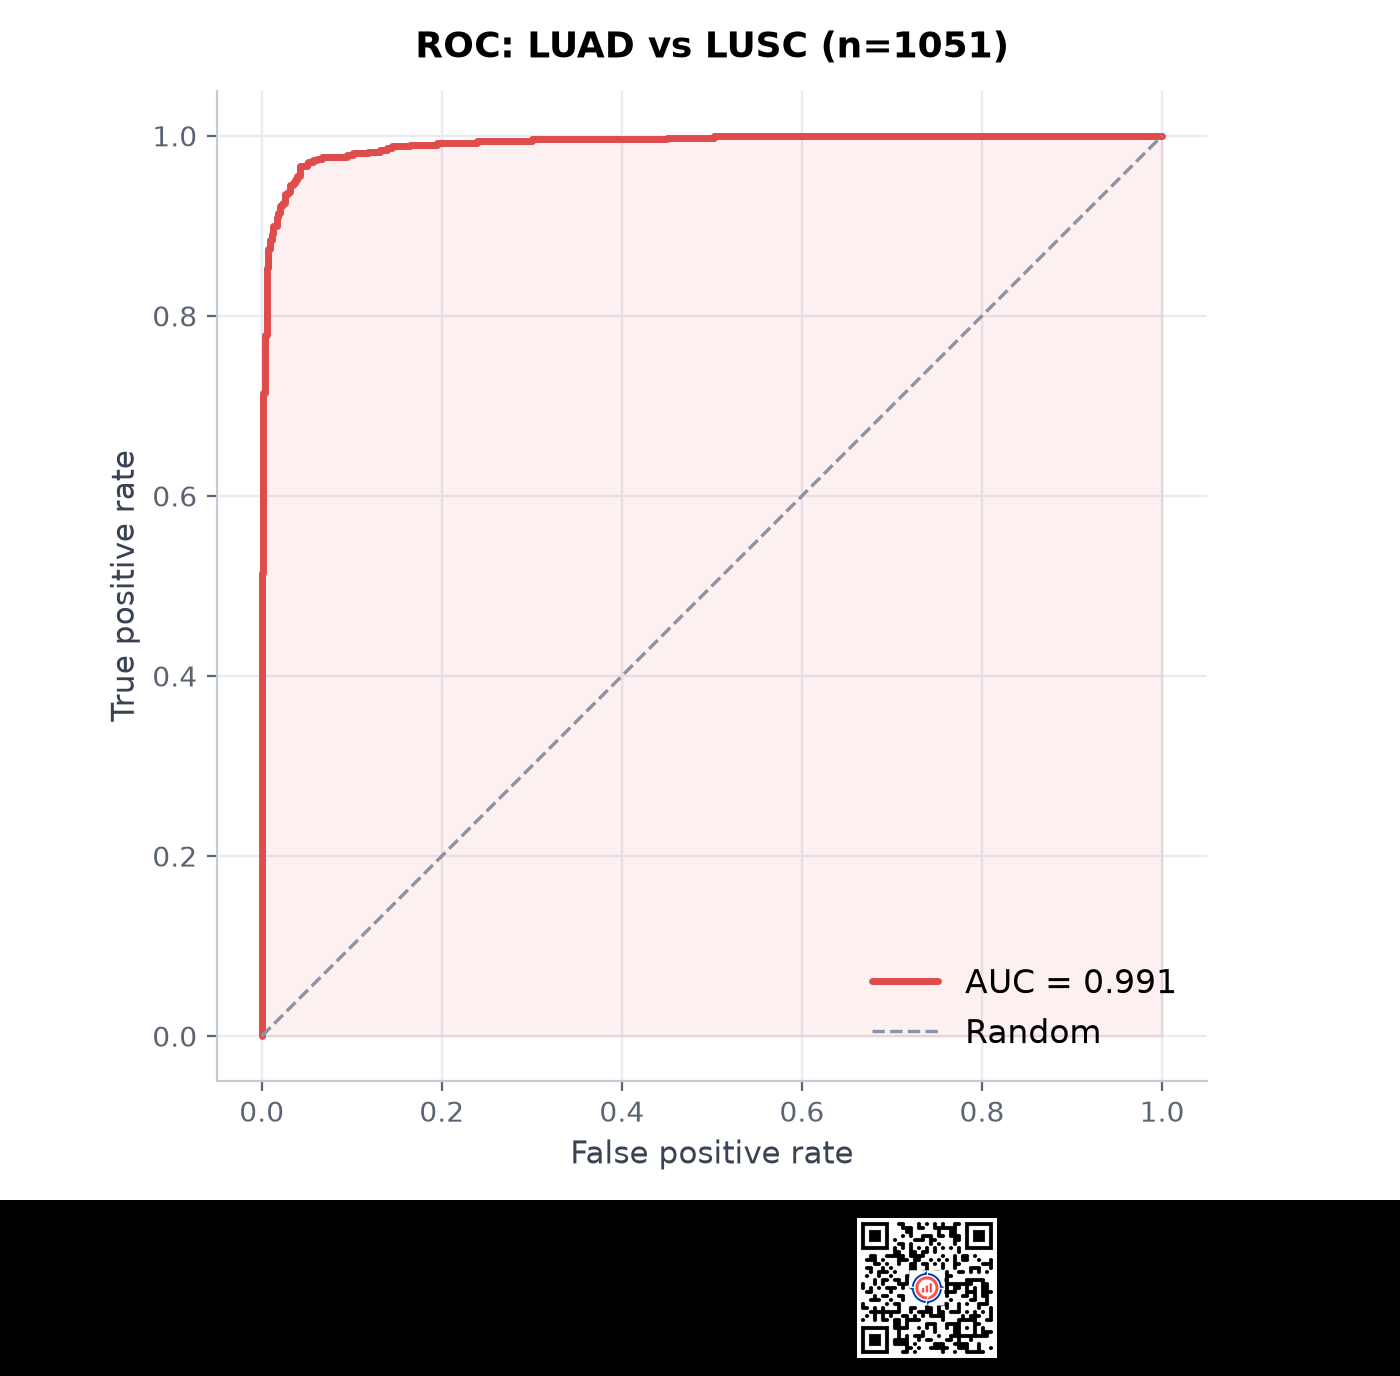


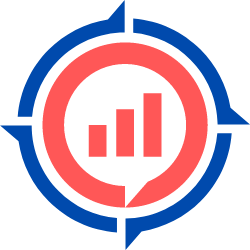
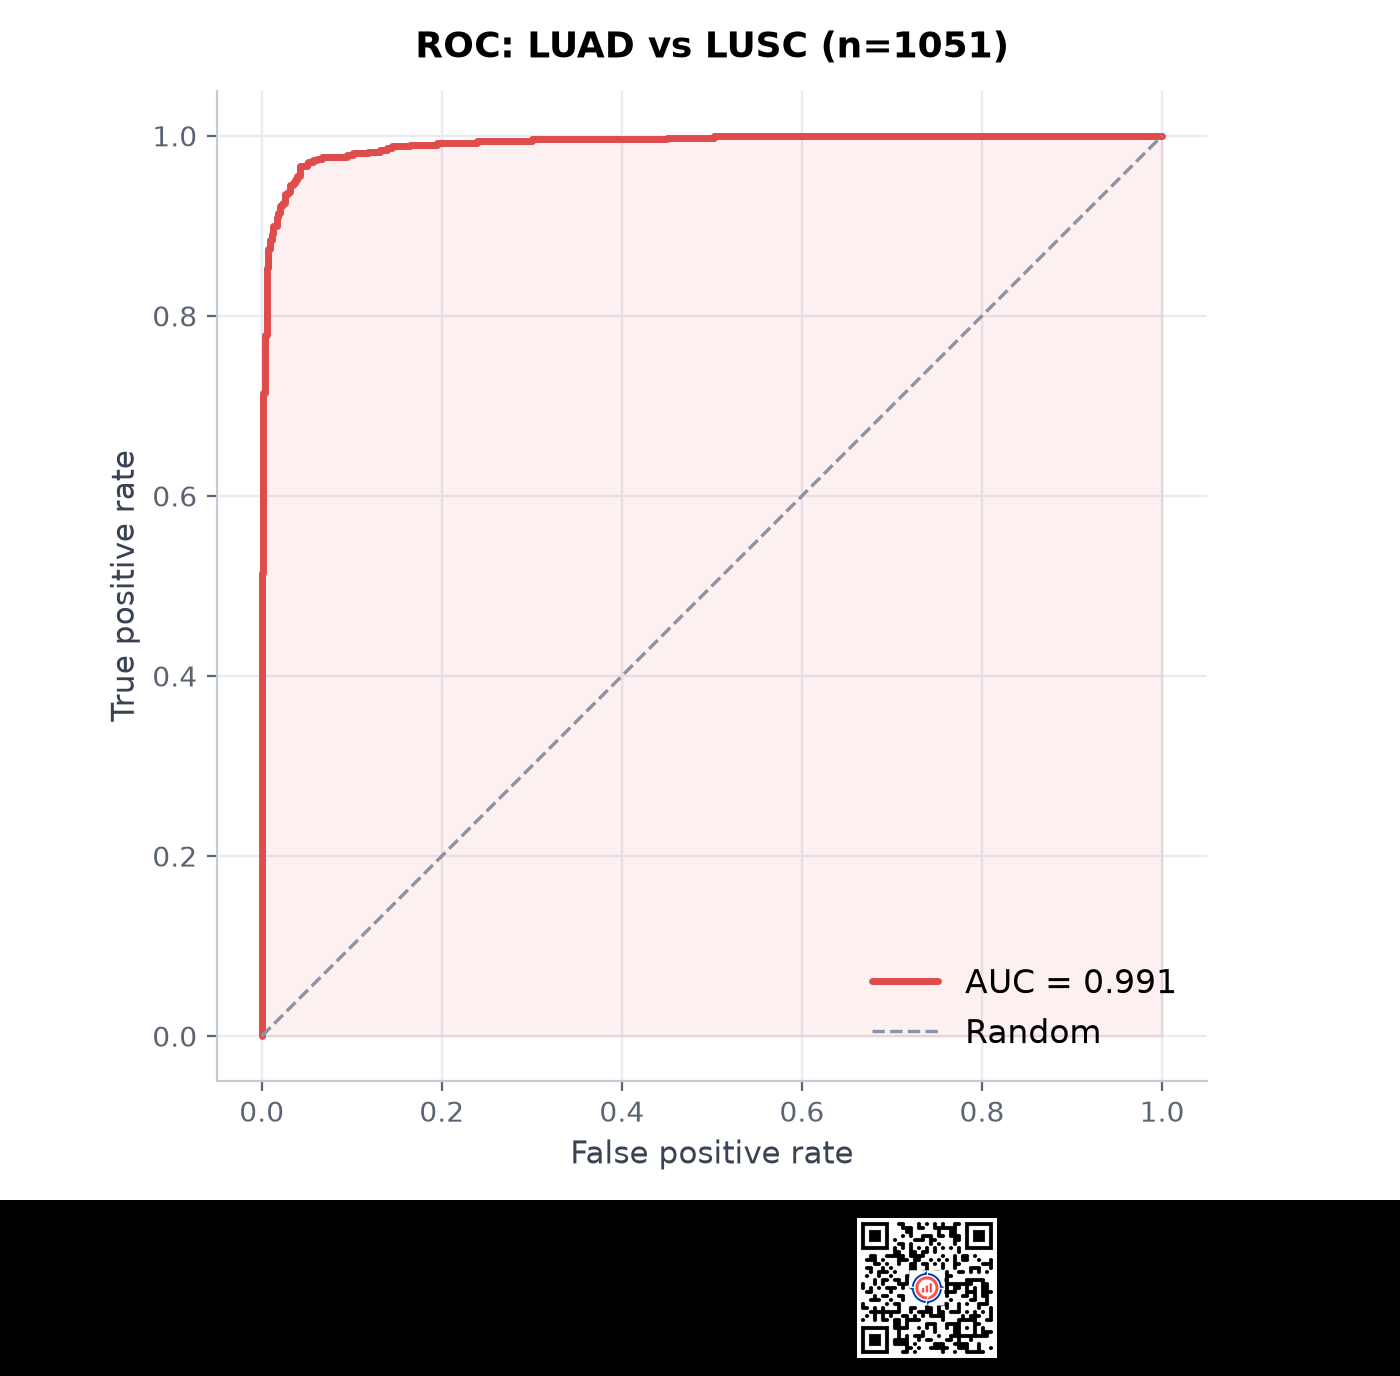
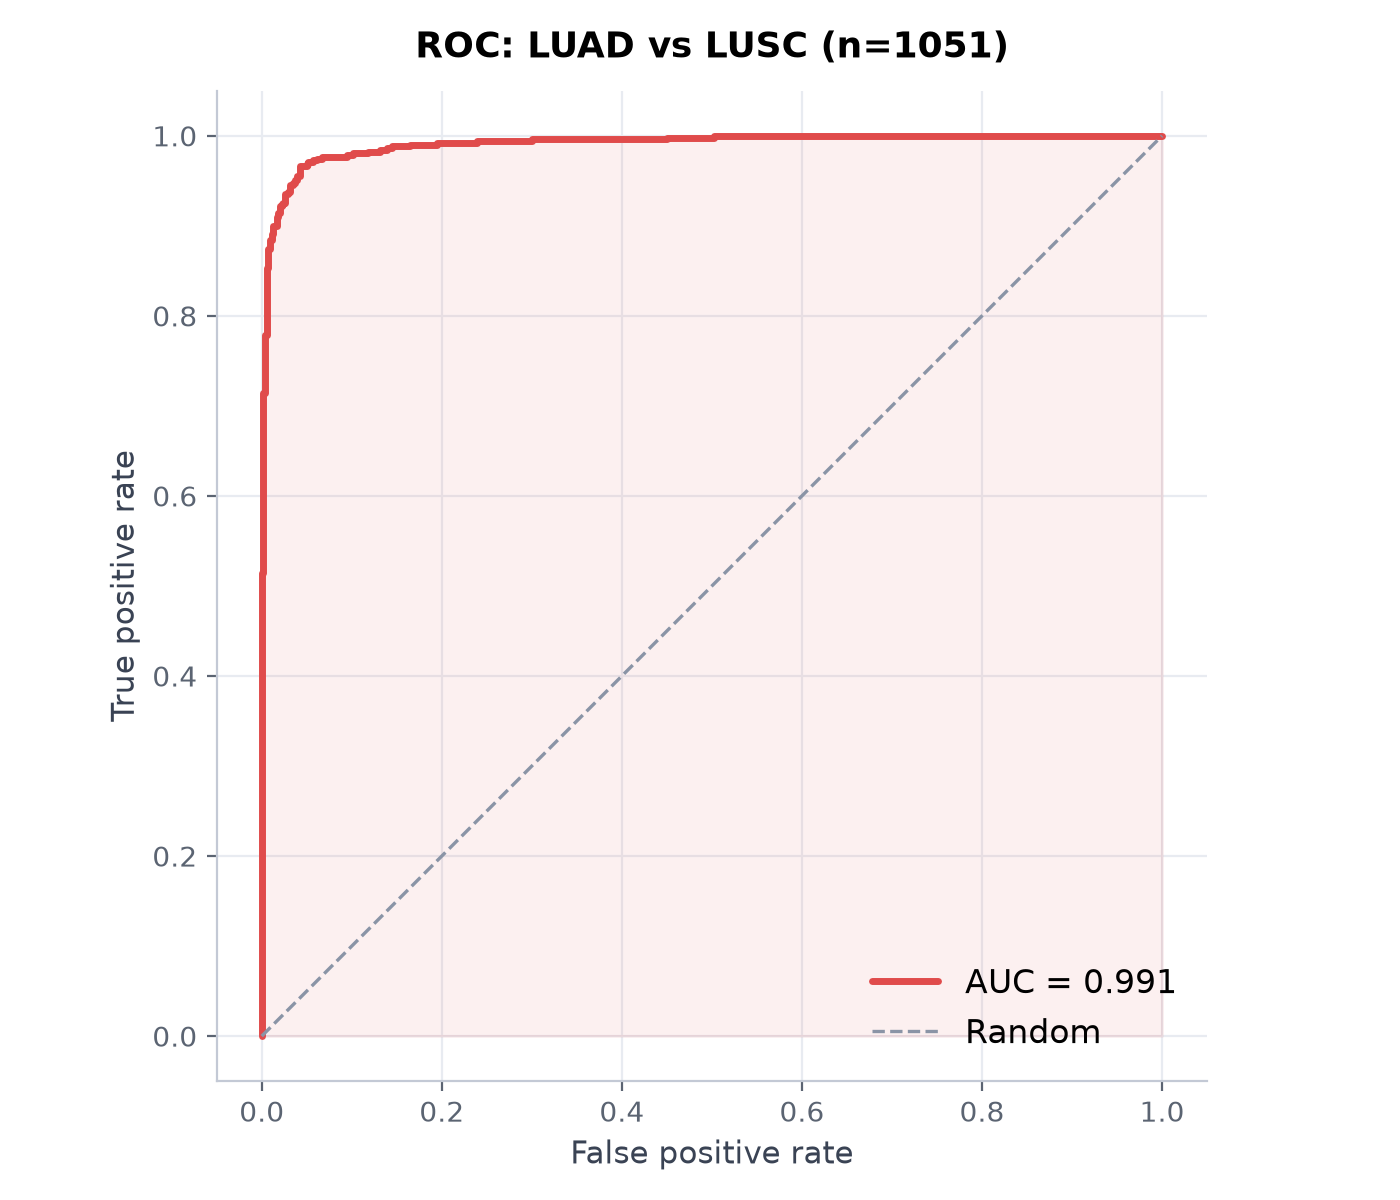
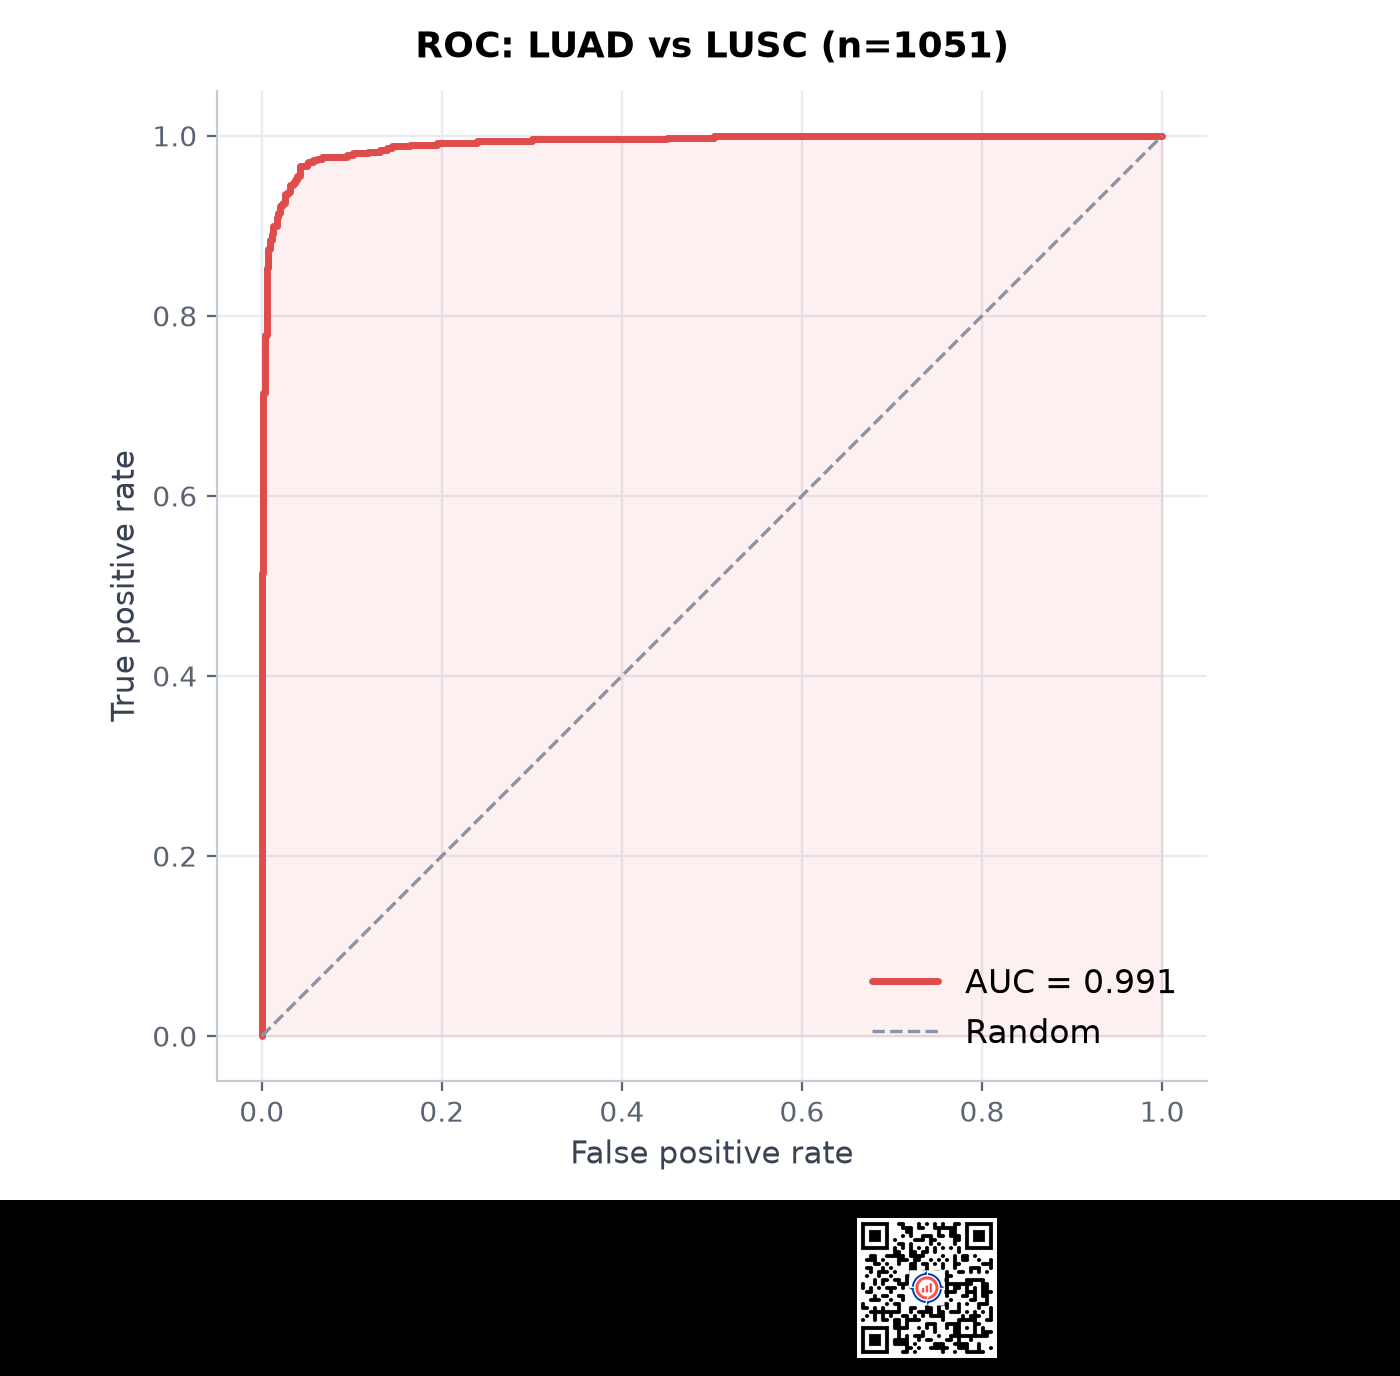
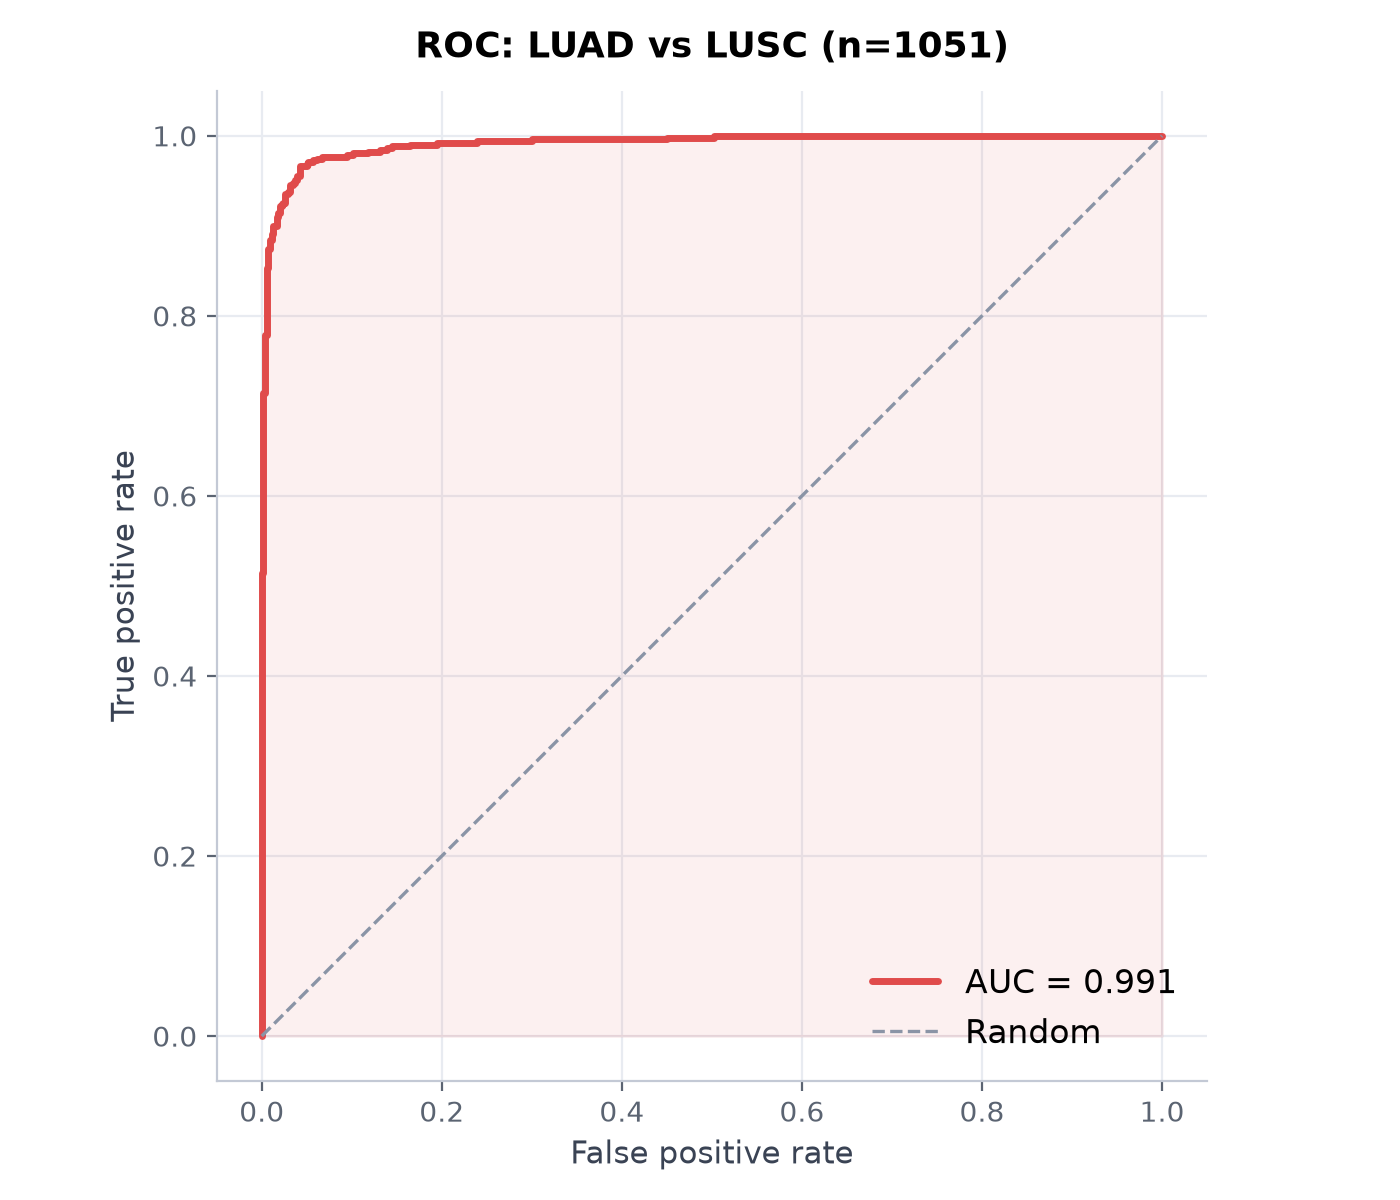

In [5]:
# Run the cross-validation once, here in the host notebook
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
y_proba = cross_val_predict(
    LogisticRegression(l1_ratio=1, C=0.1, solver="liblinear", random_state=42),
    X_scaled, y, cv=cv, method="predict_proba",
)[:, 1]


@reproducible(
    packages={
        "np": "numpy",
        "plt": "matplotlib.pyplot",
        "sklearn": "sklearn"
    },
    interactive=True
)
def plot_roc(
    y_true=StaticParam(y),
    y_score=StaticParam(y_proba),
    clinical_df=StaticParam(clf_df),
    gender: str = DropdownParam("All", choices=["All", "male", "female"]),
    stage: str = DropdownParam("All", choices=["All", "I", "II", "III", "IV"])
):
    from sklearn.metrics import roc_curve
    from sklearn.metrics import auc
    mask = np.ones(len(clinical_df), dtype=bool)
    if gender != "All":
        mask &= (clinical_df["gender"].values == gender)
    if stage != "All":
        mask &= (clinical_df["stage_simple"].values == stage)

    y_sub = np.asarray(y_true)[mask]
    p_sub = np.asarray(y_score)[mask]

    if len(np.unique(y_sub)) < 2:
        print(f"Insufficient data: n={len(y_sub)}, classes={np.unique(y_sub)}")
        return

    fpr, tpr, _ = roc_curve(y_sub, p_sub)
    roc_auc = auc(fpr, tpr)

    subtitle_parts = [f"n={len(y_sub)}"]
    if gender != "All":
        subtitle_parts.append(gender)
    if stage != "All":
        subtitle_parts.append(f"Stage {stage}")
    subtitle = " | ".join(subtitle_parts)

    # Styled explicitly (not via rcParams): the GoFigr portal re-renders this
    # function in a clean room, so the look must travel with the code.
    coral, neutral, ink = "#e04b4b", "#8a94a6", "#3a4354"
    fig, ax = plt.subplots(figsize=(7, 6), dpi=125)
    ax.fill_between(fpr, tpr, color=coral, alpha=0.08)
    ax.plot(fpr, tpr, color=coral, lw=2.5, label=f"AUC = {roc_auc:.3f}",
            solid_capstyle="round")
    ax.plot([0, 1], [0, 1], color=neutral, lw=1.2, linestyle="--", label="Random")
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(color="#e8ebf1", linewidth=0.8)
    ax.set_axisbelow(True)
    ax.set_xlabel("False positive rate", color=ink)
    ax.set_ylabel("True positive rate", color=ink)
    ax.set_title(f"ROC: LUAD vs LUSC ({subtitle})", fontsize=13,
                 fontweight="bold", pad=12)
    ax.legend(loc="lower right", fontsize=12, frameon=False)
    ax.set_aspect("equal")
    plt.tight_layout()
    publish(fig, target="ROC: LUAD vs LUSC classification")

plot_roc()


## Figure 3 — is the model learning real biology?

A classifier can score well for the wrong reasons. As a final check, we
compare the model's top genes against plain differential expression (mean
log2 fold-change between the subtypes) — two very different ways of ranking
genes. Strong overlap in the labeled upper-right and lower-left corners
means the classifier is leaning on genuinely subtype-specific biology, not
statistical noise.

Top 50 ML genes: 49
Top 50 DE genes: 50
Overlap: 9 (18%)


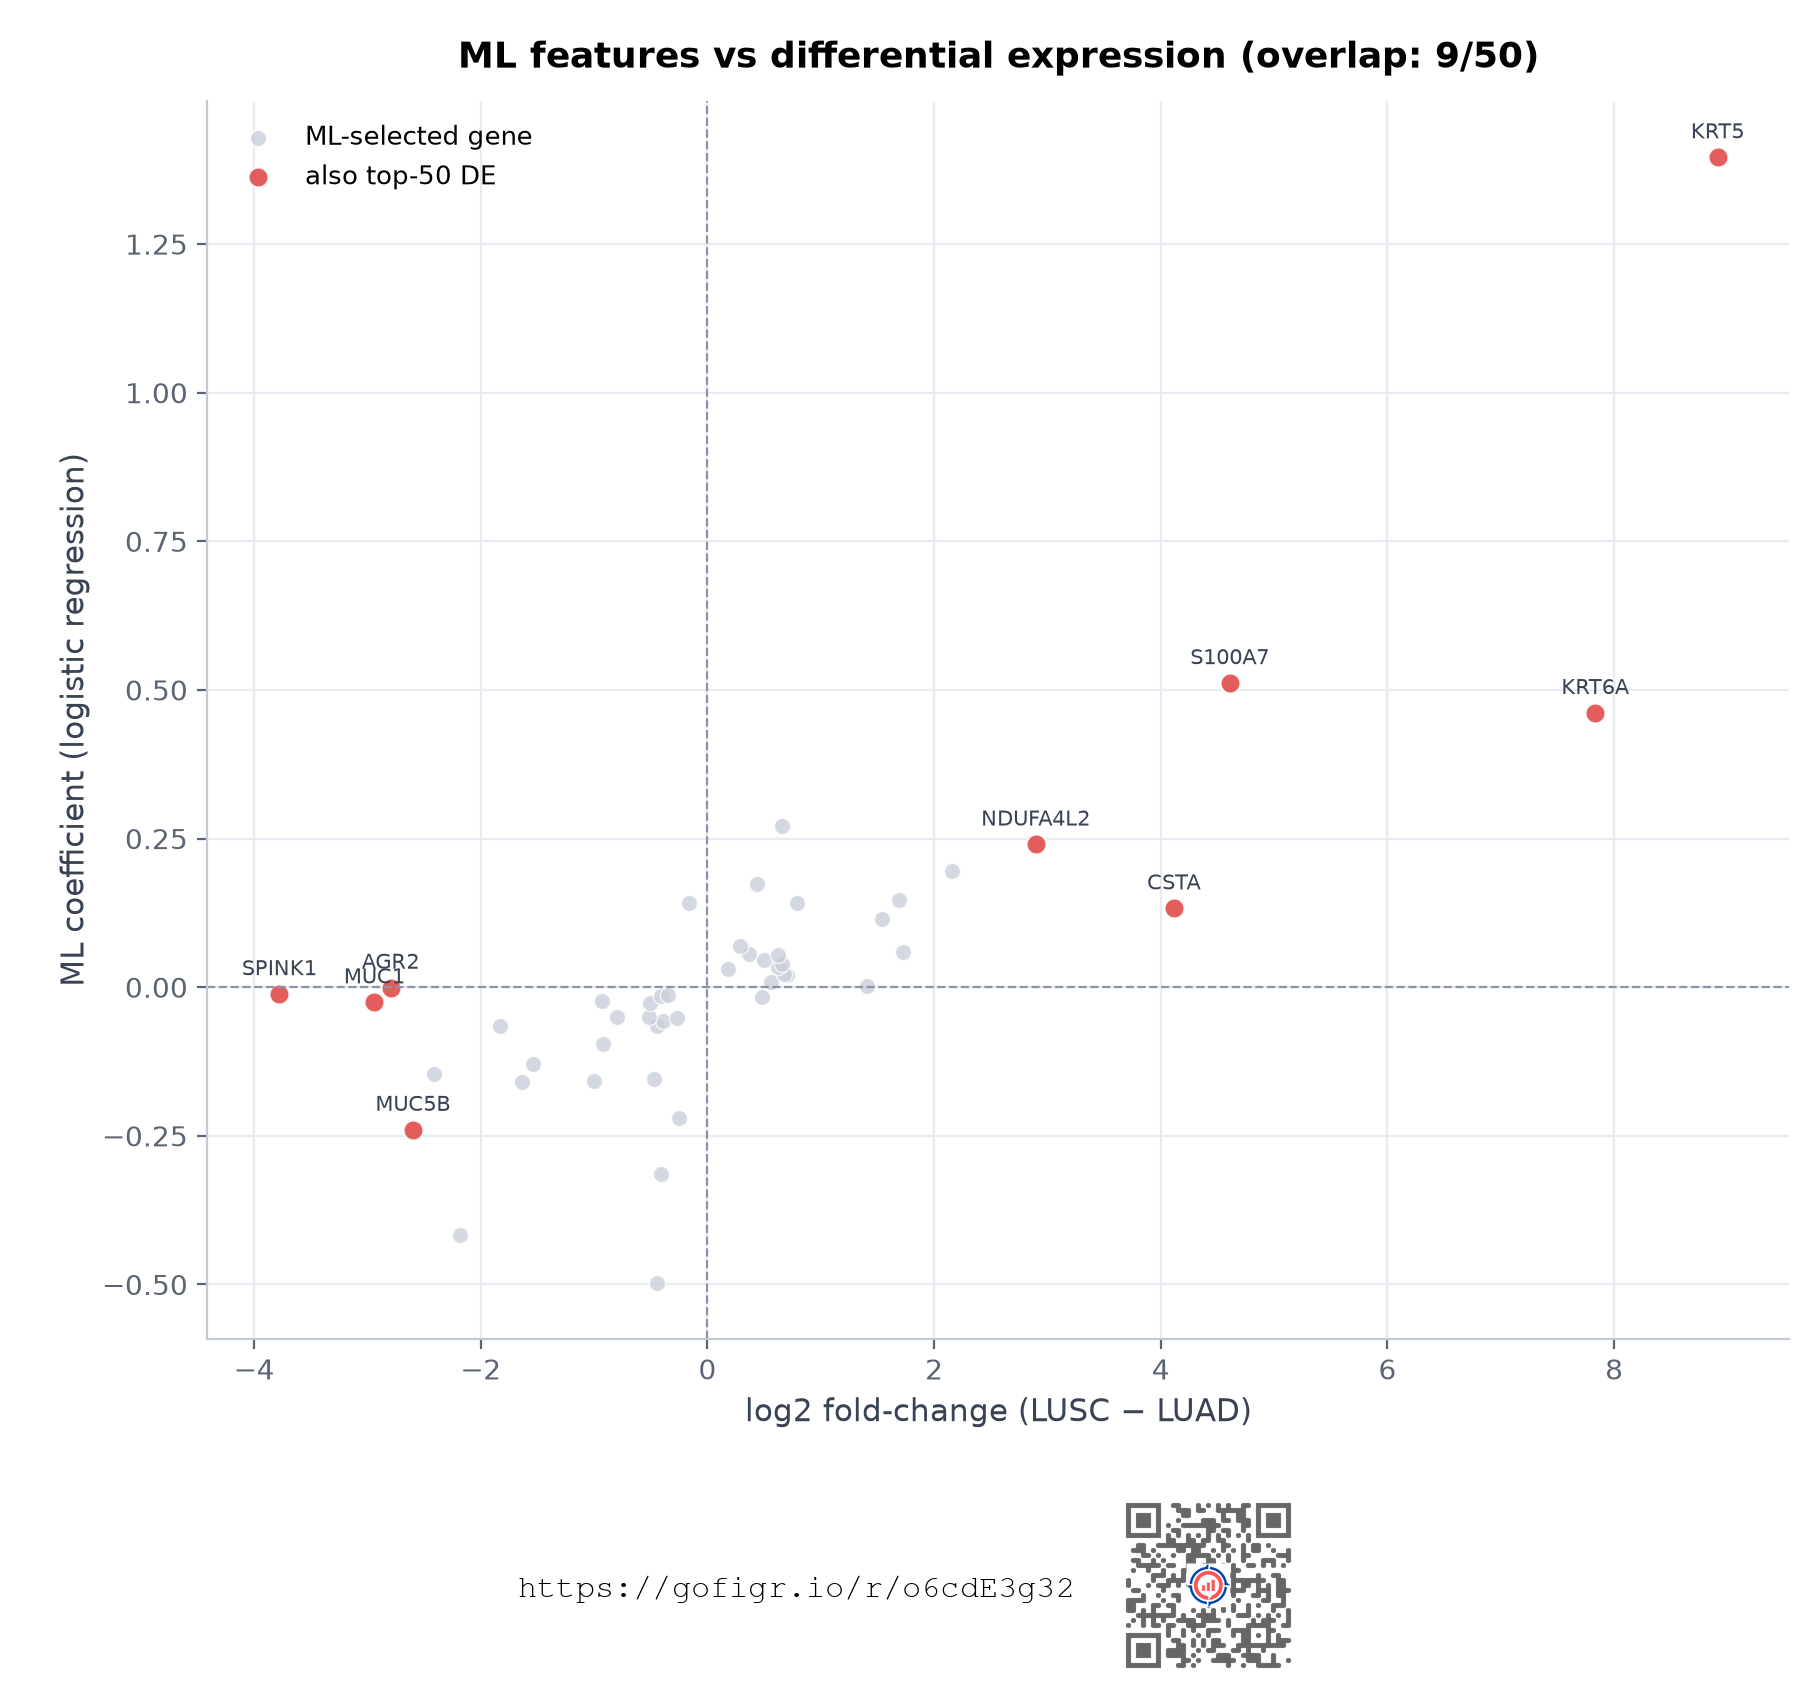


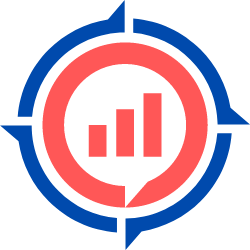
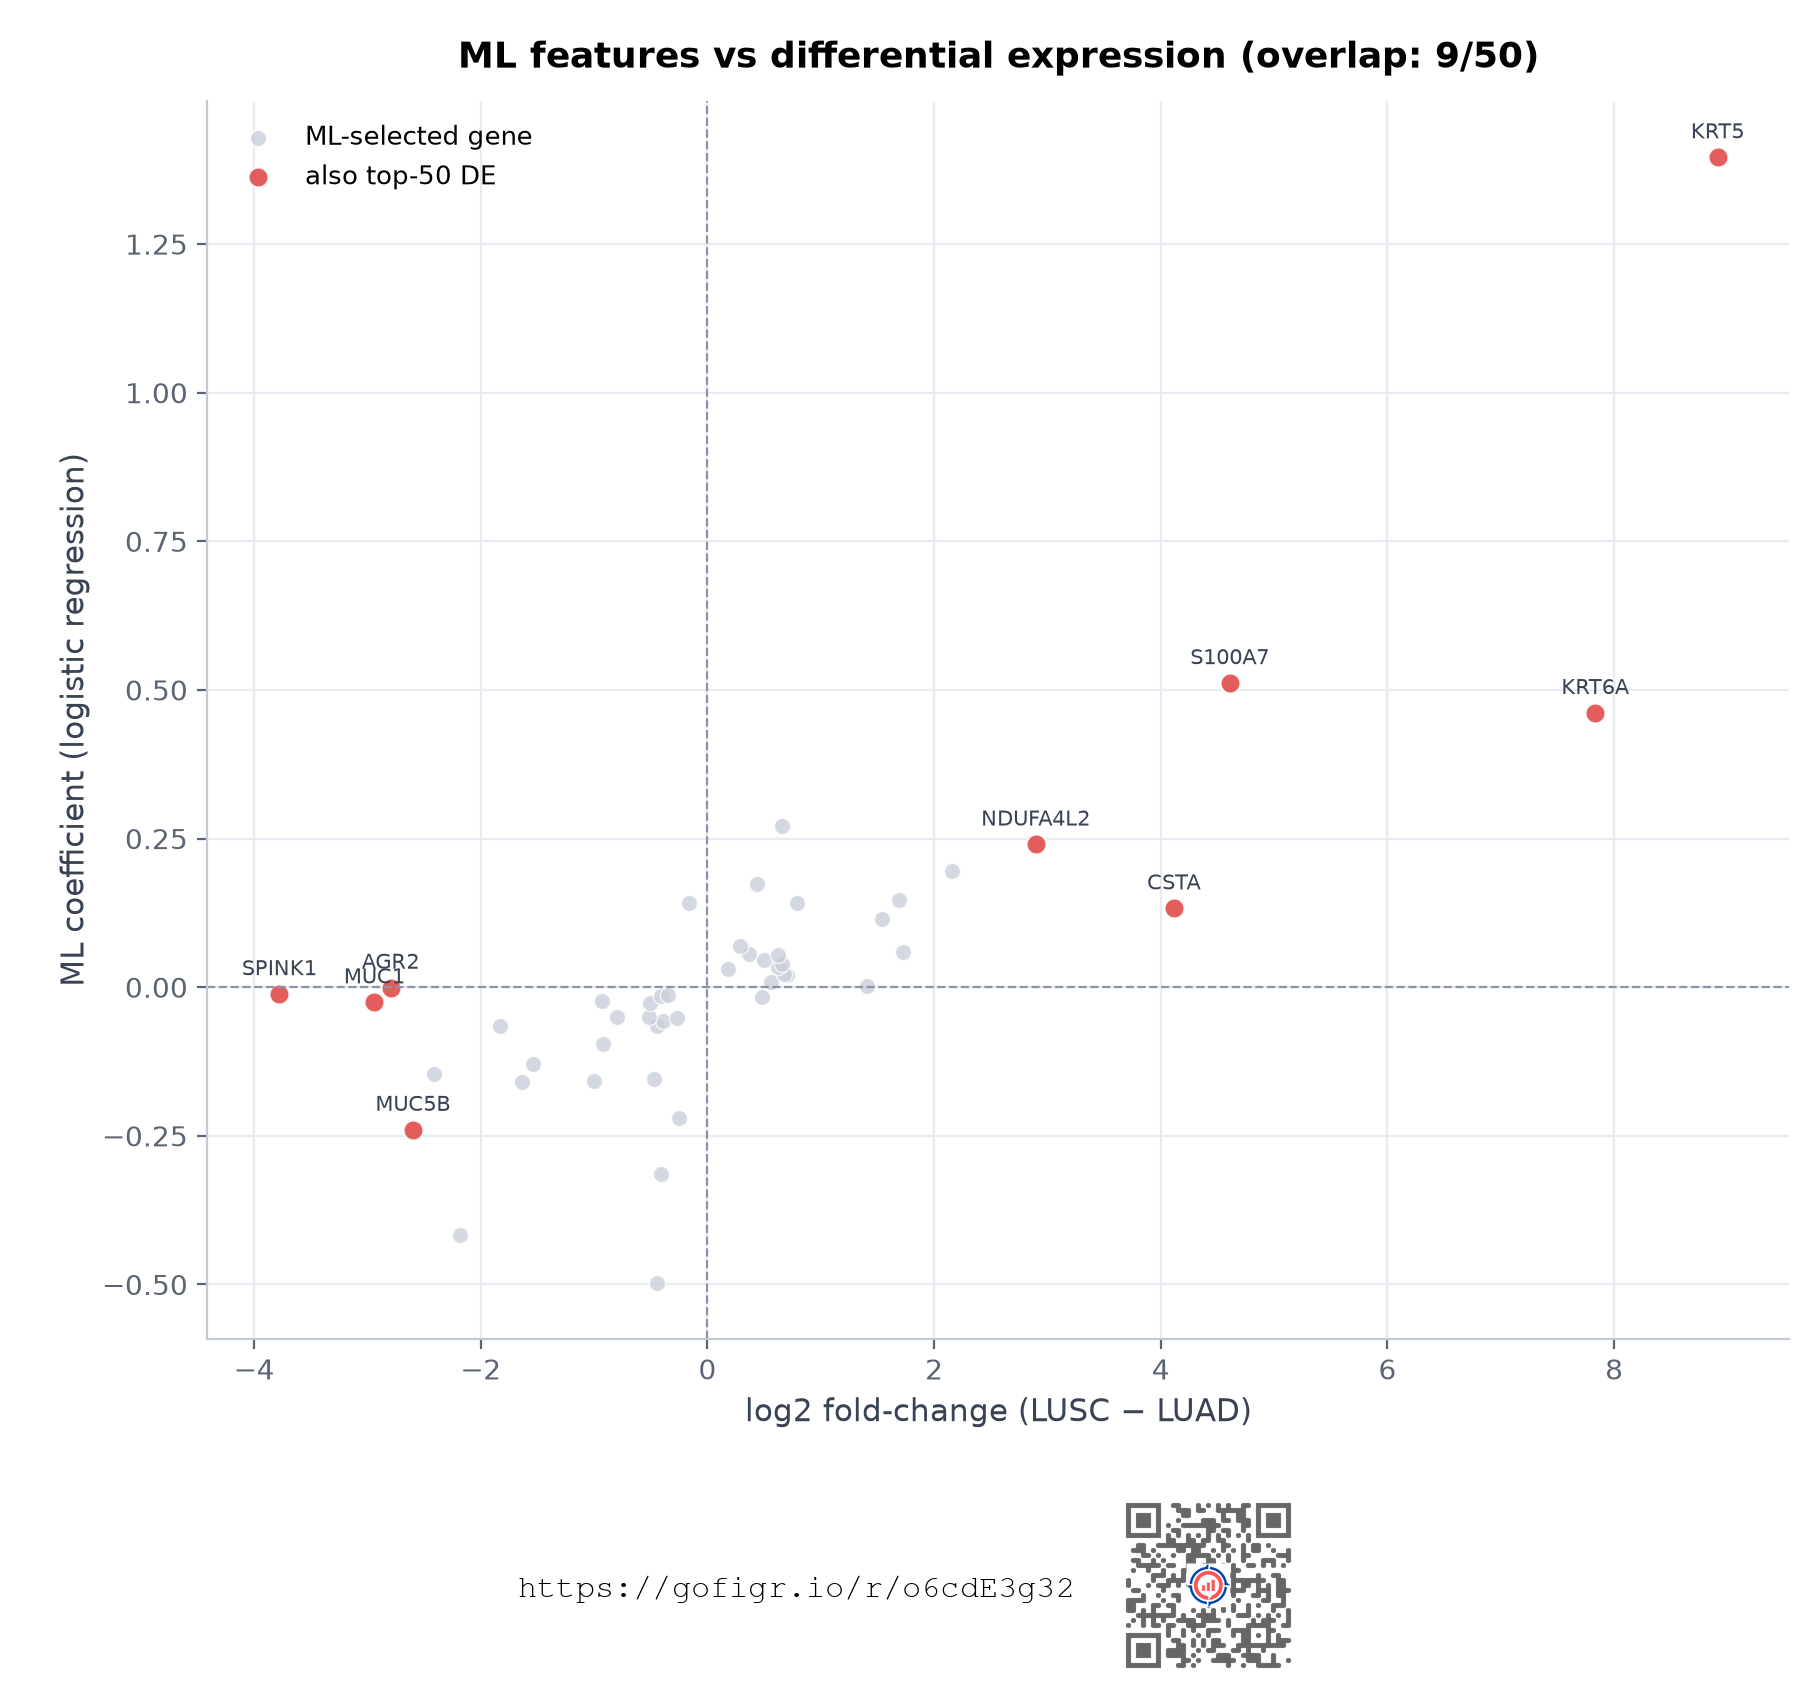
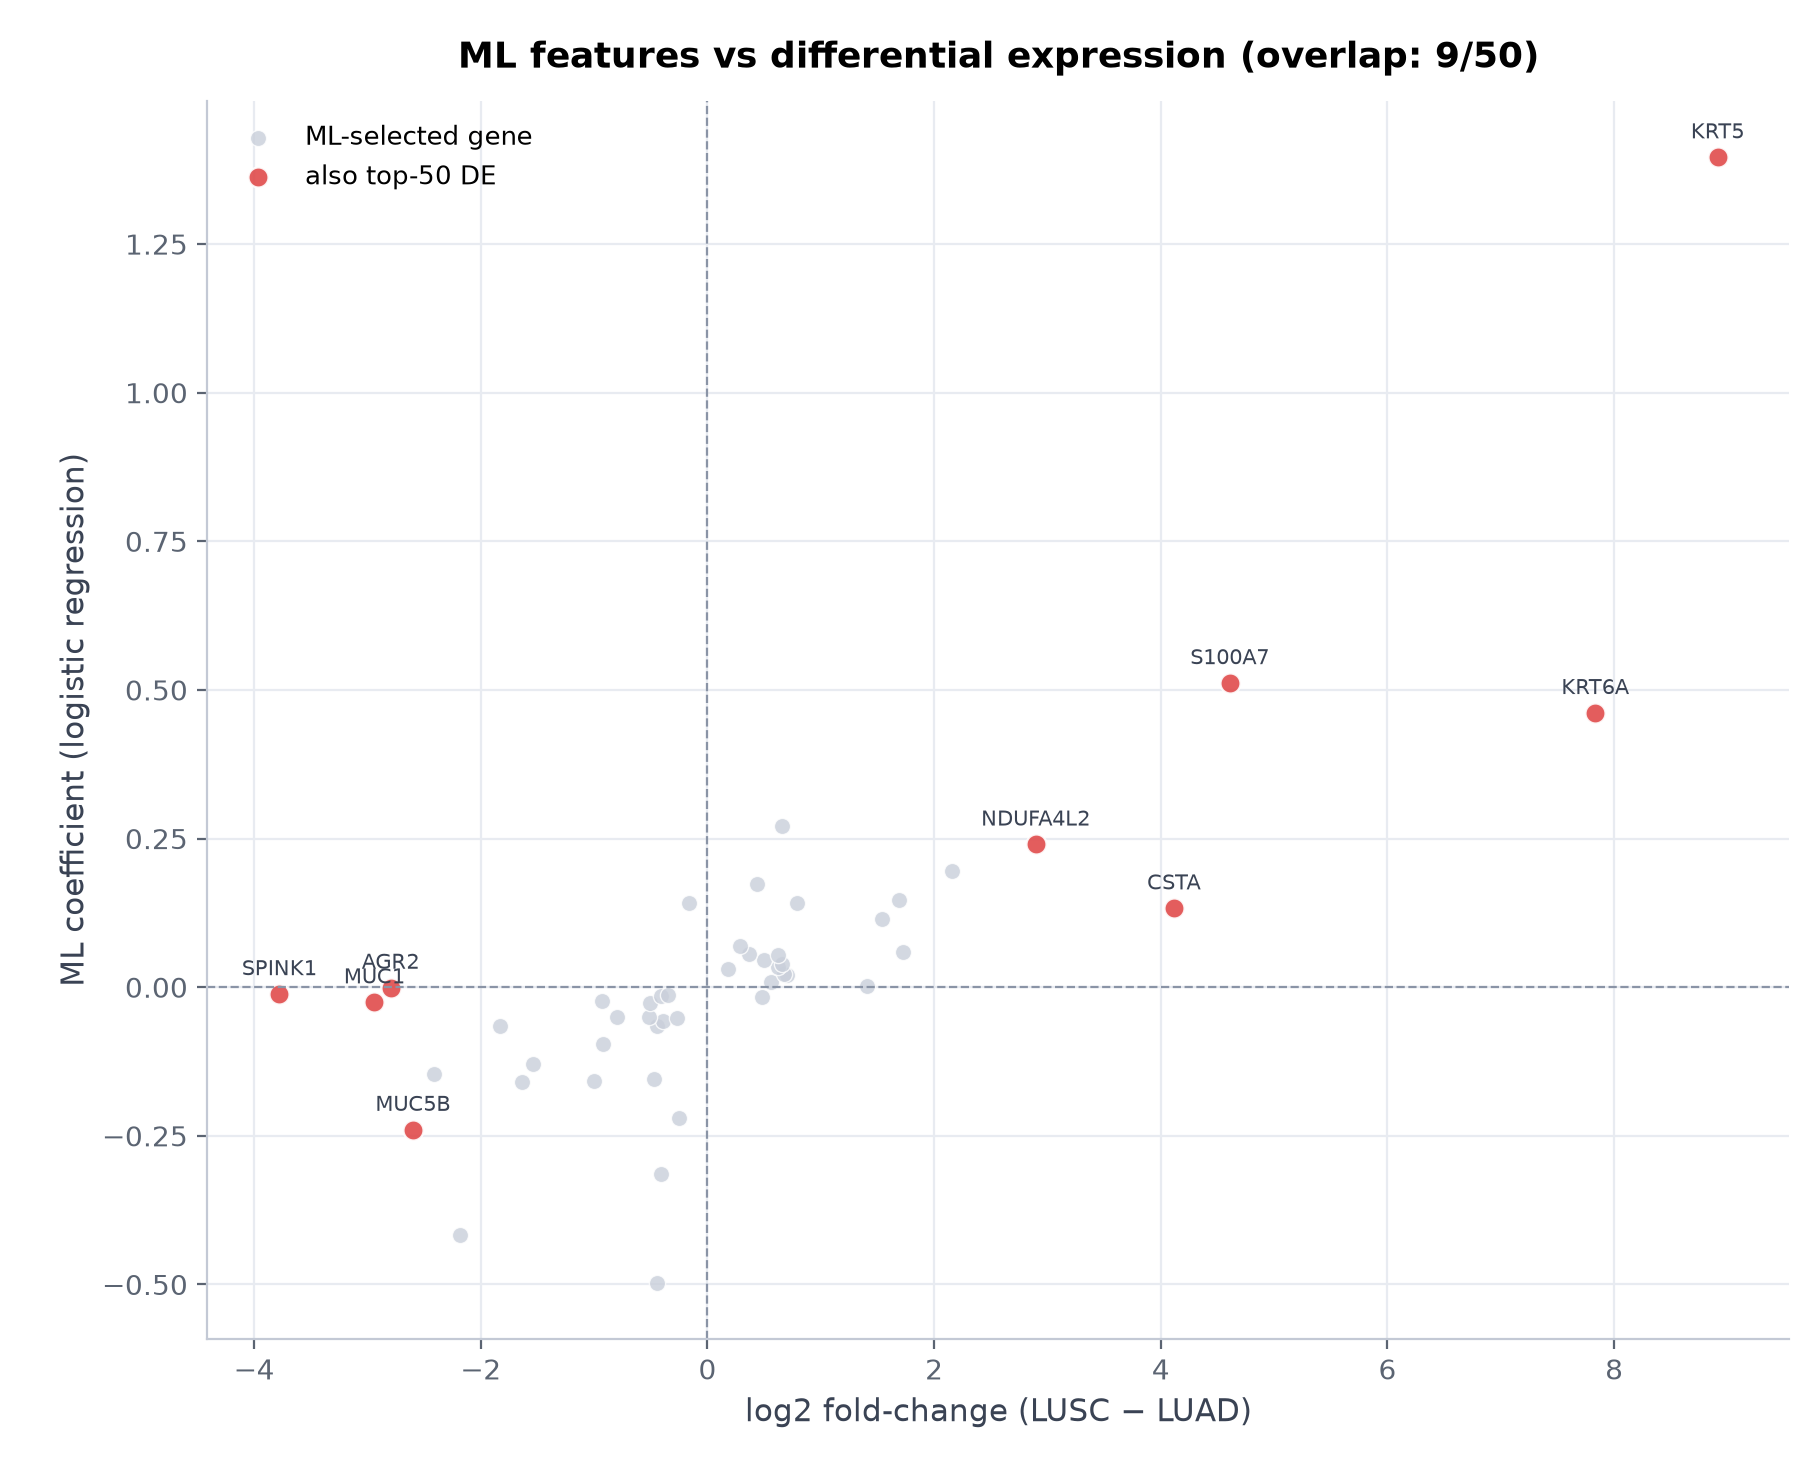
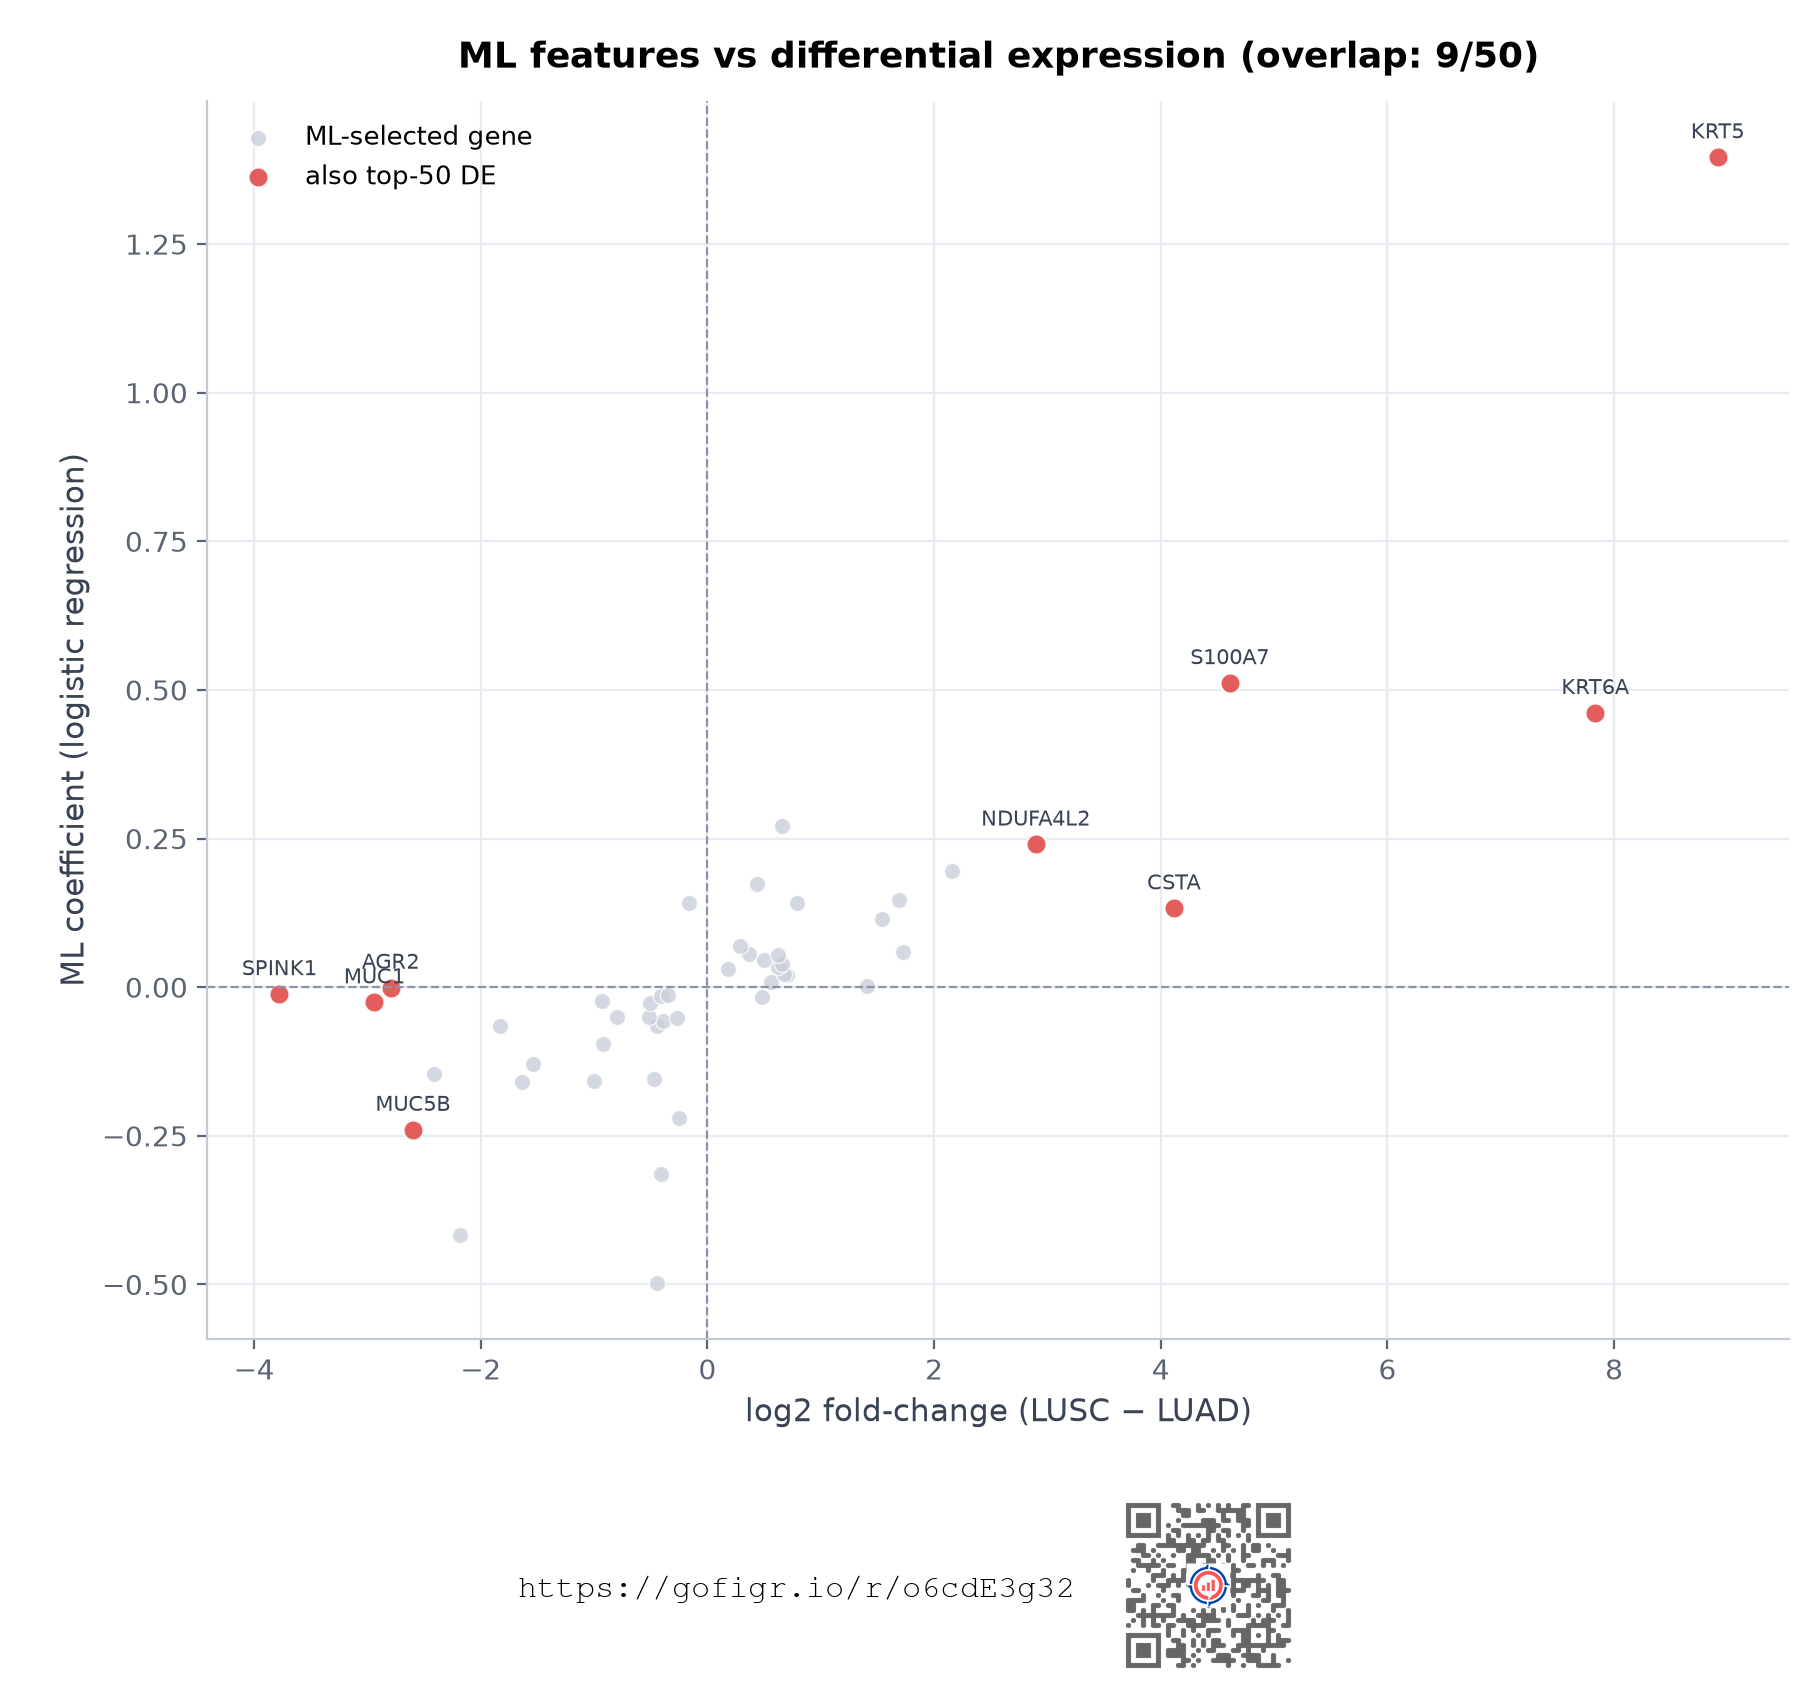
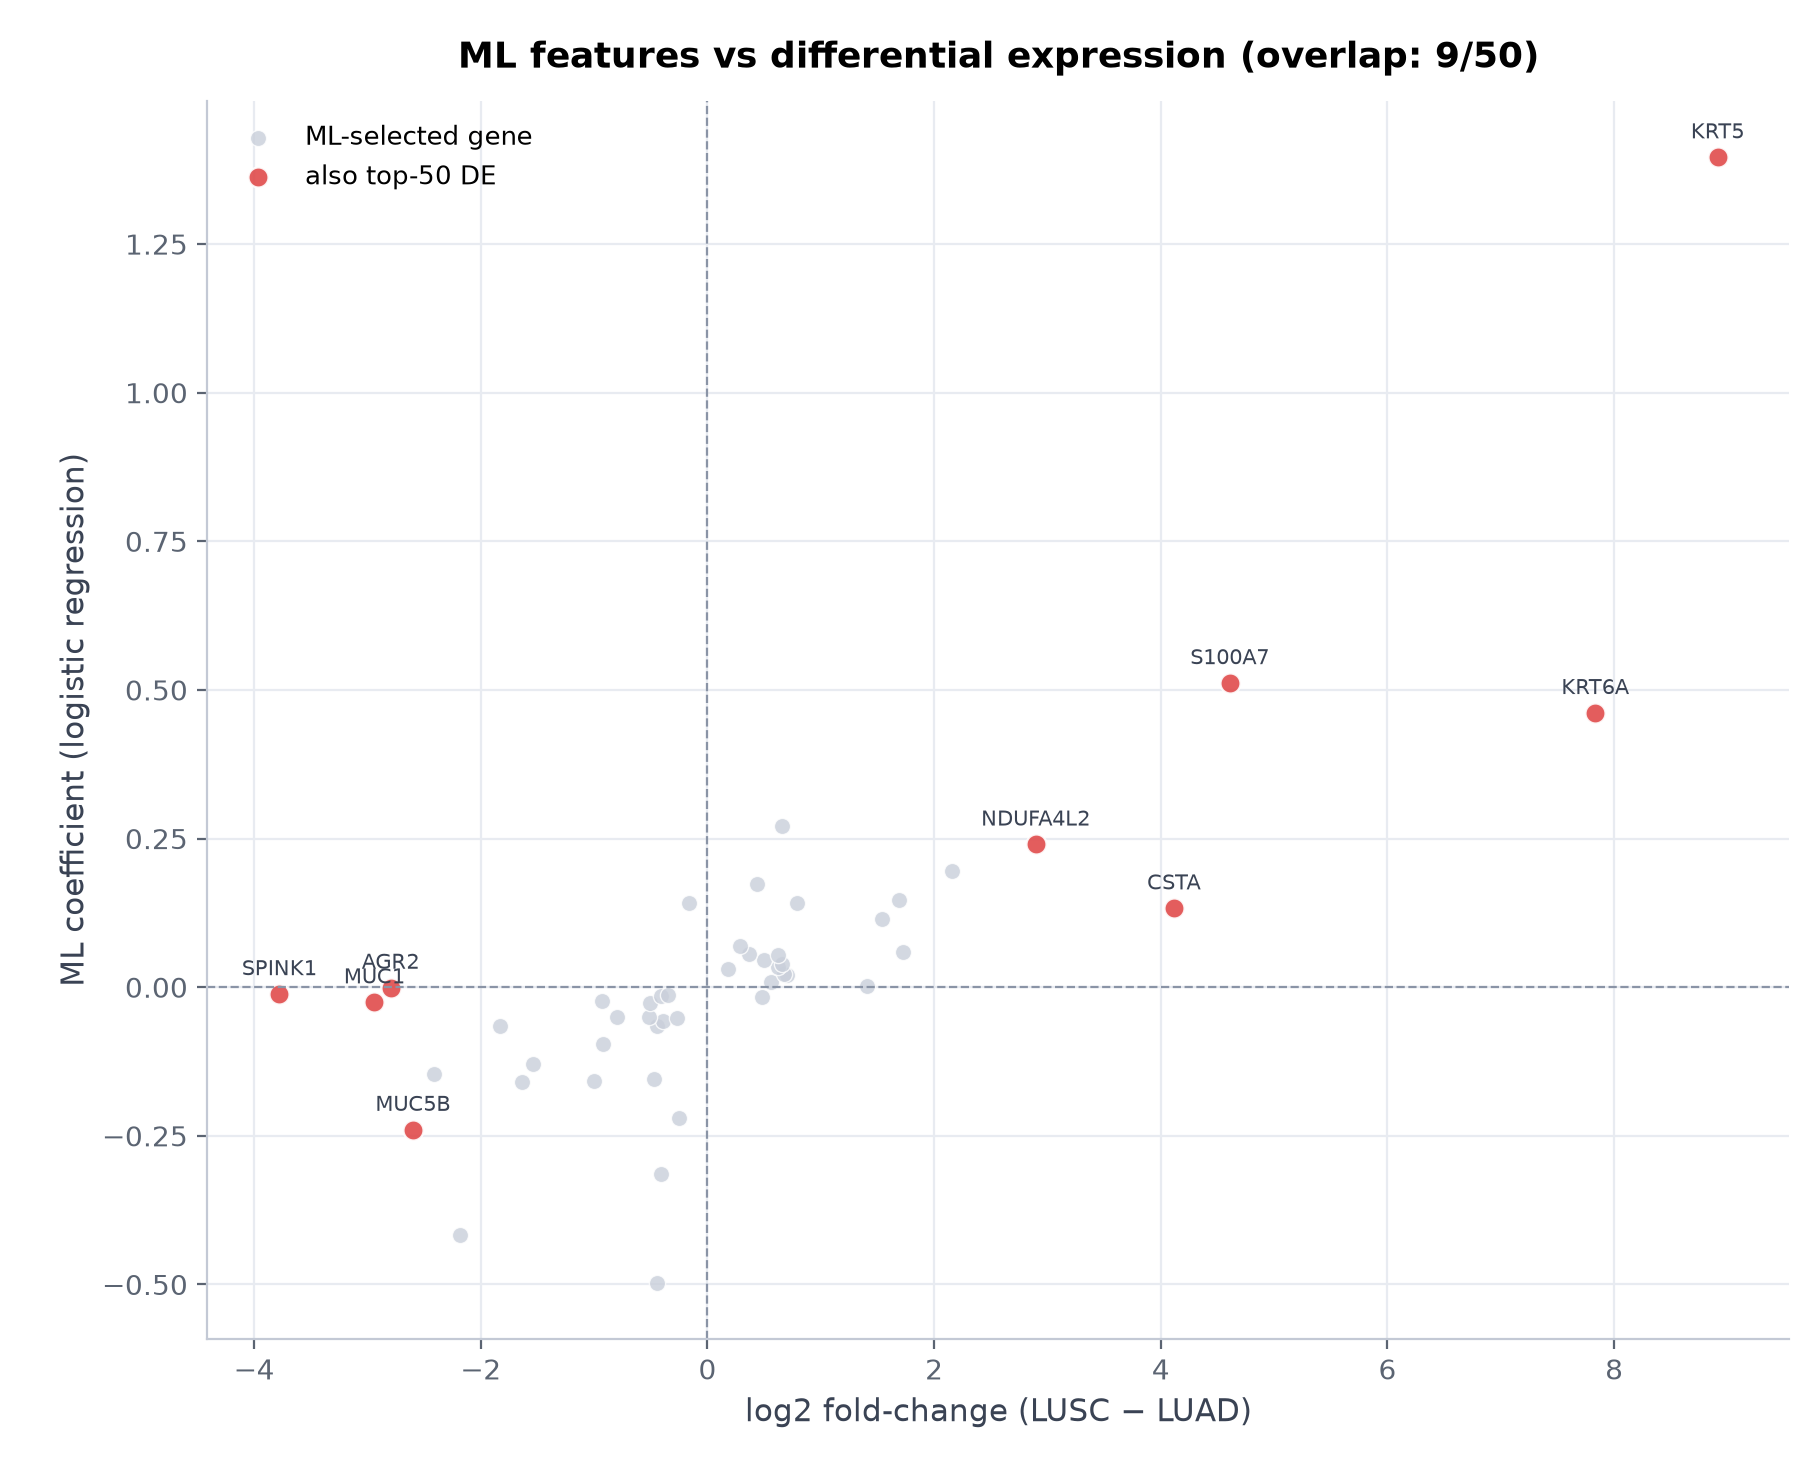

In [6]:
# Compute DE fold-changes: mean expression difference between the subtypes
luad_mask = y == 0
lusc_mask = y == 1
log2fc = X[lusc_mask].mean(axis=0) - X[luad_mask].mean(axis=0)
fc_series = pd.Series(log2fc, index=gene_names)

# Top 50 by each method
n_compare = 50
top_ml = set(nonzero.abs().nlargest(n_compare).index)
top_de = set(fc_series.abs().nlargest(n_compare).index)
overlap = top_ml & top_de

print(f"Top {n_compare} ML genes: {len(top_ml)}")
print(f"Top {n_compare} DE genes: {len(top_de)}")
print(f"Overlap: {len(overlap)} ({100*len(overlap)/n_compare:.0f}%)")

# Scatter: ML coefficient vs DE fold-change for all non-zero ML genes
plot_df = pd.DataFrame({
    "log2fc": fc_series[nonzero.index],
    "ml_coef": nonzero
})
plot_df["in_top_de"] = plot_df.index.isin(top_de)

fig, ax = plt.subplots(figsize=(8, 6))
rest = plot_df[~plot_df["in_top_de"]]
hits = plot_df[plot_df["in_top_de"]]
ax.scatter(rest["log2fc"], rest["ml_coef"], c="#c9cfda", s=34, alpha=0.8,
           edgecolors="white", linewidth=0.5, label="ML-selected gene")
ax.scatter(hits["log2fc"], hits["ml_coef"], c=LUSC_CORAL, s=52, alpha=0.9,
           edgecolors="white", linewidth=0.8, label="also top-50 DE")

# Label the overlap genes
for gene in list(overlap)[:15]:  # label up to 15 to avoid crowding
    row = plot_df.loc[gene]
    ax.annotate(gene, (row["log2fc"], row["ml_coef"]),
                fontsize=7.5, color=INK, ha="center", va="bottom",
                xytext=(0, 5), textcoords="offset points")

ax.axhline(0, color=NEUTRAL, linewidth=0.8, linestyle="--")
ax.axvline(0, color=NEUTRAL, linewidth=0.8, linestyle="--")
ax.set_xlabel("log2 fold-change (LUSC \u2212 LUAD)")
ax.set_ylabel("ML coefficient (logistic regression)")
ax.set_title(f"ML features vs differential expression (overlap: {len(overlap)}/{n_compare})")
ax.legend(loc="upper left", fontsize=9.5)
plt.tight_layout()
plt.show()


## What just happened — and what to try next

Three figures now live in your GoFigr account, each carrying the code, data
fingerprint, and environment that made it. From here:

1. **See the provenance.** Open [app.gofigr.io](https://app.gofigr.io),
   click a figure, and explore what was captured alongside the image.
2. **Make a revision.** Change something above — try `C=0.01` in Figure 1's
   model (fewer, stronger genes) or `top_n = 30` — and re-run the cell.
   GoFigr stores a **new revision** next to the original, and you can compare
   the two side by side in the portal. Nothing is ever overwritten.
3. **Slice the interactive figure.** Find Figure 2 in the portal and use the
   dropdowns to re-render the ROC for any gender/stage subgroup.
4. **Analyze your own data.** Drop a CSV or parquet into the file browser and
   ask the **GoFigr Assistant** (chat panel on the left) to build an analysis
   — everything it creates publishes the same way.

Prefer R? The same analysis is available as a Quarto report:
[`tcga_lung_analysis.qmd`](tcga_lung_analysis.qmd), published with the
`gofigR` client.